# Aprendizaje de Máquinas (Machine Learning)

## Integrantes:
- Lucrecia Meo Rodriguez
- Luka Benjamin Malegni


## TP Seguros Médicos, Enunciado

Una prepaga quiere optimizar costos decidiendo los montos que cobra mensualmente a sus socios de manera más eficaz. Para ello cuenta con una base de datos, disponible aquí, en la que se resumen algunas características de sus asociados y el monto que pagan de cuota médico/asistencial.

Desarrollar los algoritmos apropiados basados en los contenidos vistos en la materia para poder, a partir de los datos disponibles, construir un modelo que permita predecir el monto que debe cobrársele a la persona por su seguro médico.

Evaluar los resultados del algoritmo escogido, y comparar con otras soluciones posibles a través de métricas apropiadas.

Estudiar qué características son las más relevantes al momento de determinar el valor de la cuota, para ayudar a la compañía a reconocer patrones de interés.


### 1. Configuración del ambiente

In [ ]:
%pip install -q pandas numpy matplotlib seaborn scikit-learn xgboost

from pathlib import Path
import random
import numpy as np

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
np.set_printoptions(precision=3, suppress=True)

datasets_folder = Path("data")
datasets_folder.mkdir(exist_ok=True)

### 2. Datos necesarios para trabajar


In [ ]:
import pandas as pd

insurance_dataset = {
    "url": "https://raw.githubusercontent.com/dsrscientist/dataset4/f3d6ed5581fe267d727e3780bb6406a0378ddd69/medical_cost_insurance.csv",
    "filename": datasets_folder / "insurance.csv"
}

if not insurance_dataset["filename"].exists():
    df_descargado = pd.read_csv(insurance_dataset["url"])
    df_descargado.to_csv(insurance_dataset["filename"], index=False)
    print(f"Dataset descargado en: {insurance_dataset['filename']}")
else:
    print(f"El archivo {insurance_dataset['filename']} ya existe.")

Dataset descargado en: data/insurance.csv


### 3. Exploramos datos
Abrimos los datos con Pandas para explorar

In [ ]:
import pandas as pd

# abrimos el archivo usando una función específica de pandas
raw_dataset_dataframe = pd.read_csv(insurance_dataset['filename'])
raw_dataset_dataframe

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500



Vemos que tenemos un total de 1338 filas, y que hay 7 features por muestra.

Verificamos si tenemos valores de variable nulos para establecer la acción correctiva que vamos a aplicar. Si encontramos nulos vamos a eliminar el registro.



In [ ]:
# obtenemos una tabla booleana con True donde hay valores nulos
is_nan = raw_dataset_dataframe.isnull()
# chequeamos qué filas tienen valores nulos
row_has_nan = is_nan.any(axis=1)
# nos quedamos con esas filas
rows_with_nan = raw_dataset_dataframe[row_has_nan]
# imprimimos
rows_with_nan

,age,sex,bmi,children,smoker,region,charges


No teníamos ningún valor nulo.

Ahora analizamos si hay alguna entrada duplicada:

In [ ]:

# Revisar duplicados
duplicados = raw_dataset_dataframe.duplicated().sum()
if duplicados > 0:
    raw_dataset_dataframe = raw_dataset_dataframe.drop_duplicates().reset_index(drop=True)
    print(f"Shape después de eliminar duplicados: {raw_dataset_dataframe.shape}")
else:
    print("No hay duplicados")

Shape después de eliminar duplicados: (1337, 7)


Chequeamos con qué características contamos. Vamos a:

- Interpretar las características,

- Identificar características que puedan Introducir algún sesgo en nuestros algoritmos

- Aplicar acciones correctivas.




In [ ]:
# definimos un diccionario con tags para las features que vamos a mantener y sus
# descriptiones
feature_labels = dict()
feature_labels['age']      = 'Edad del beneficiario principal en años (18-64)'
feature_labels['sex']      = 'Género biológico del beneficiario (male/female)'
feature_labels['bmi']      = 'Índice de Masa Corporal peso(kg)/altura(m)² - obesidad si BMI > 30'
feature_labels['children'] = 'Cantidad de hijos o dependientes cubiertos por el seguro (0-5)'
feature_labels['smoker']   = 'Indica si el beneficiario es fumador activo (yes/no)'
feature_labels['region']   = 'Región geográfica de residencia en EEUU (northeast/northwest/southeast/southwest)'
feature_labels['charges']  = 'TARGET - Monto anual en USD cobrado por el seguro médico'

# Verificar
print("=== Feature Labels - Seguro Médico ===")
for col, label in feature_labels.items():
    print(f"  {col:10} → {label}")

# Verificar que todas las columnas del dataset están definidas
print("\n=== Columnas en dataset vs labels definidos ===")
for col in raw_dataset_dataframe.columns:
    estado = "OK" if col in feature_labels else "Ko SIN DEFINIR"
    print(f"  {estado} {col}")

=== Feature Labels - Seguro Médico ===
  age        → Edad del beneficiario principal en años (18-64)
  sex        → Género biológico del beneficiario (male/female)
  bmi        → Índice de Masa Corporal peso(kg)/altura(m)² - obesidad si BMI > 30
  children   → Cantidad de hijos o dependientes cubiertos por el seguro (0-5)
  smoker     → Indica si el beneficiario es fumador activo (yes/no)
  region     → Región geográfica de residencia en EEUU (northeast/northwest/southeast/southwest)
  charges    → TARGET - Monto anual en USD cobrado por el seguro médico

=== Columnas en dataset vs labels definidos ===
  OK age
  OK sex
  OK bmi
  OK children
  OK smoker
  OK region
  OK charges


Identificamos caracteristicas que puedan introducir sesgo

/tmp/ipykernel_29127/2728549158.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=raw_dataset_dataframe, x='sex', y='charges',
/tmp/ipykernel_29127/2728549158.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=raw_dataset_dataframe, x='smoker', y='charges',


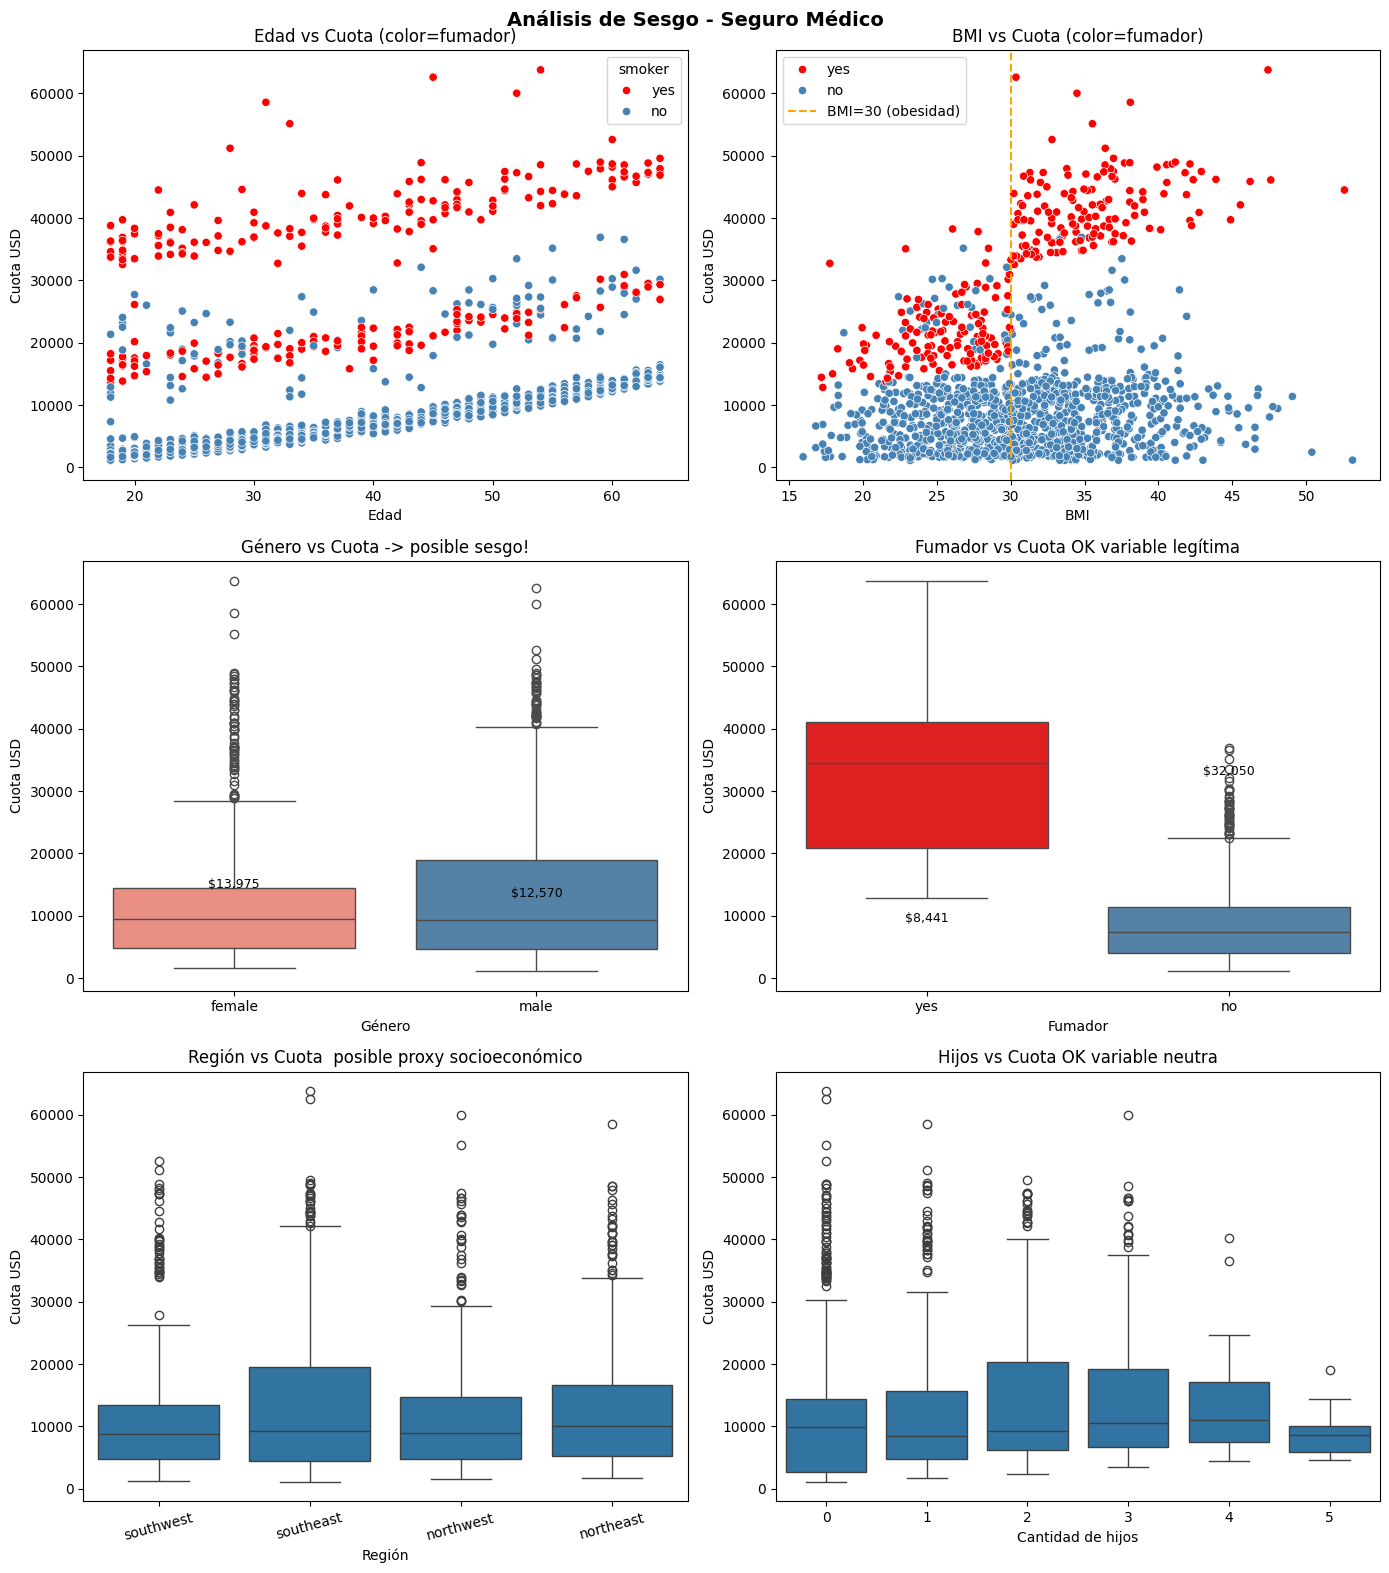

=== ANÁLISIS DE SESGO POR VARIABLE ===

1. GÉNERO (sex):
            mean   median  count
sex                             
female  12569.58  9412.96    662
male    13975.00  9377.90    675
   Diferencia promedio M-F: $1,405.42
   Sesgo:  SIGNIFICATIVO

2. FUMADOR (smoker):
            mean    median  count
smoker                           
no       8440.66   7345.73   1063
yes     32050.23  34456.35    274
   Diferencia promedio: $23,609.57
   Justificación: OK actuarialmente válido

3. REGIÓN (region):
               mean    median  count
region                              
northeast  13406.38  10057.65    324
northwest  12450.84   8976.98    324
southeast  14735.41   9294.13    364
southwest  12346.94   8798.59    325
   Sesgo: verificar correlación con nivel socioeconómico

4. BMI:
              mean    median  count
obeso                              
no obeso  10713.67   8604.48    631
obeso     15572.04  10003.65    706
   Diferencia promedio: $4,858.38

5. DISTRIBUCIÓN DEL TARG

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(3, 2, figsize=(14, 16))
fig.suptitle('Análisis de Sesgo - Seguro Médico', fontsize=14, fontweight='bold')

#  Age vs Charges
sns.scatterplot(data=raw_dataset_dataframe, x='age', y='charges', hue='smoker',
                palette={'yes':'red','no':'steelblue'}, ax=axes[0,0])
axes[0,0].set_title('Edad vs Cuota (color=fumador)')
axes[0,0].set_xlabel('Edad')
axes[0,0].set_ylabel('Cuota USD')

#  BMI vs Charges
sns.scatterplot(data=raw_dataset_dataframe, x='bmi', y='charges', hue='smoker',
                palette={'yes':'red','no':'steelblue'}, ax=axes[0,1])
axes[0,1].axvline(x=30, color='orange', linestyle='--', label='BMI=30 (obesidad)')
axes[0,1].legend()
axes[0,1].set_title('BMI vs Cuota (color=fumador)')
axes[0,1].set_xlabel('BMI')
axes[0,1].set_ylabel('Cuota USD')

#  Sex vs Charges
sns.boxplot(data=raw_dataset_dataframe, x='sex', y='charges',
            palette={'male':'steelblue','female':'salmon'}, ax=axes[1,0])
axes[1,0].set_title('Género vs Cuota -> posible sesgo!')
axes[1,0].set_xlabel('Género')
axes[1,0].set_ylabel('Cuota USD')

#  Media por género
for i, sex in enumerate(['male','female']):
    media = raw_dataset_dataframe[raw_dataset_dataframe['sex']==sex]['charges'].mean()
    axes[1,0].text(i, media+500, f'${media:,.0f}', ha='center', fontsize=9)

#  Smoker vs Charges
sns.boxplot(data=raw_dataset_dataframe, x='smoker', y='charges',
            palette={'yes':'red','no':'steelblue'}, ax=axes[1,1])
axes[1,1].set_title('Fumador vs Cuota OK variable legítima')
axes[1,1].set_xlabel('Fumador')
axes[1,1].set_ylabel('Cuota USD')

for i, sm in enumerate(['no','yes']):
    media = raw_dataset_dataframe[raw_dataset_dataframe['smoker']==sm]['charges'].mean()
    axes[1,1].text(i, media+500, f'${media:,.0f}', ha='center', fontsize=9)

#  Region vs Charges
sns.boxplot(data=raw_dataset_dataframe, x='region', y='charges', ax=axes[2,0])
axes[2,0].set_title('Región vs Cuota  posible proxy socioeconómico')
axes[2,0].set_xlabel('Región')
axes[2,0].set_ylabel('Cuota USD')
axes[2,0].tick_params(axis='x', rotation=15)

#  Children vs Charges
sns.boxplot(data=raw_dataset_dataframe, x='children', y='charges', ax=axes[2,1])
axes[2,1].set_title('Hijos vs Cuota OK variable neutra')
axes[2,1].set_xlabel('Cantidad de hijos')
axes[2,1].set_ylabel('Cuota USD')

plt.tight_layout()
plt.show()

#  Análisis numérico de sesgo
print("=== ANÁLISIS DE SESGO POR VARIABLE ===\n")

print("1. GÉNERO (sex):")
print(raw_dataset_dataframe.groupby('sex')['charges'].agg(['mean','median','count']).round(2))
diff_sex = raw_dataset_dataframe[raw_dataset_dataframe['sex']=='male']['charges'].mean() - raw_dataset_dataframe[raw_dataset_dataframe['sex']=='female']['charges'].mean()
print(f"   Diferencia promedio M-F: ${diff_sex:,.2f}")
print(f"   Sesgo: {' SIGNIFICATIVO' if abs(diff_sex) > 1000 else 'OK BAJO'}\n")

print("2. FUMADOR (smoker):")
print(raw_dataset_dataframe.groupby('smoker')['charges'].agg(['mean','median','count']).round(2))
diff_smoker = raw_dataset_dataframe[raw_dataset_dataframe['smoker']=='yes']['charges'].mean() - raw_dataset_dataframe[raw_dataset_dataframe['smoker']=='no']['charges'].mean()
print(f"   Diferencia promedio: ${diff_smoker:,.2f}")
print(f"   Justificación: OK actuarialmente válido\n")

print("3. REGIÓN (region):")
print(raw_dataset_dataframe.groupby('region')['charges'].agg(['mean','median','count']).round(2))
print(f"   Sesgo: verificar correlación con nivel socioeconómico\n")

print("4. BMI:")
raw_dataset_dataframe['obeso'] = raw_dataset_dataframe['bmi'].apply(lambda x: 'obeso' if x >= 30 else 'no obeso')
print(raw_dataset_dataframe.groupby('obeso')['charges'].agg(['mean','median','count']).round(2))
diff_bmi = raw_dataset_dataframe[raw_dataset_dataframe['obeso']=='obeso']['charges'].mean() - raw_dataset_dataframe[raw_dataset_dataframe['obeso']=='no obeso']['charges'].mean()
print(f"   Diferencia promedio: ${diff_bmi:,.2f}\n")

print("5. DISTRIBUCIÓN DEL TARGET (charges):")
print(f"   Media:    ${raw_dataset_dataframe['charges'].mean():,.2f}")
print(f"   Mediana:  ${raw_dataset_dataframe['charges'].median():,.2f}")
print(f"   Skewness: {raw_dataset_dataframe['charges'].skew():.3f}")
print(f"   → {' distribución sesgada ' if raw_dataset_dataframe['charges'].skew() > 1 else 'OK distribución aceptable'}")

**Conclusion** sobre esta analisis.   El Genero se identifica como una variable de sesgo sifnificativo  Los hombres pagan en promedio 11% más que las mujeres.
Fumador vs No fumador es diferencia más grande de todas, casi 4x más.  Region, el sureste paga un poco mas. Observaremos este comportamiento y BMI las personas de peso mayor a 30 pagan mas. Esta variable se puede pasar a binaria.

La media es mucho mayor que la mediana, indicando que hay valores muy altos que tiran la distribución hacia arriba. Aplicaremos una transformación logarítmica antes de entrenar.

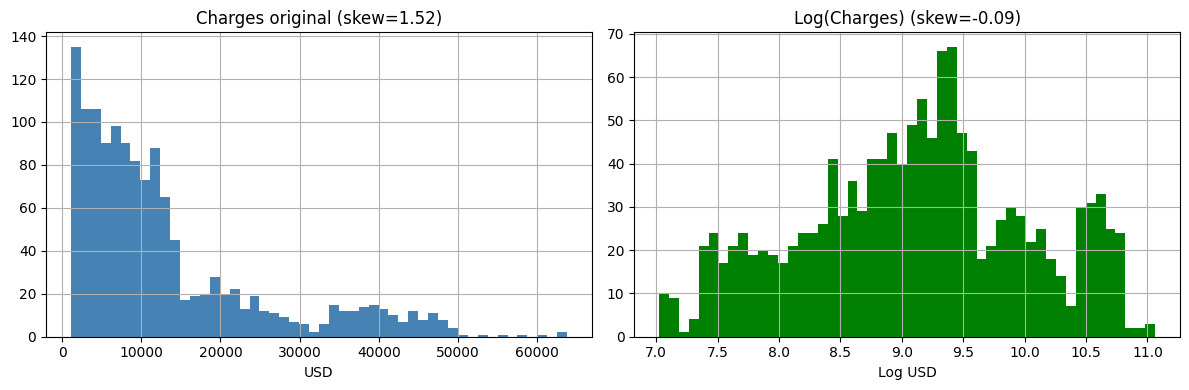

Skewness original:       1.515
Skewness log-transform:  -0.090


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribución original
raw_dataset_dataframe['charges'].hist(bins=50, ax=axes[0], color='steelblue')
axes[0].set_title(f'Charges original (skew={raw_dataset_dataframe["charges"].skew():.2f})')
axes[0].set_xlabel('USD')

# Distribución con log-transform
np.log(raw_dataset_dataframe['charges']).hist(bins=50, ax=axes[1], color='green')
axes[1].set_title(f'Log(Charges) (skew={np.log(raw_dataset_dataframe["charges"]).skew():.2f})')
axes[1].set_xlabel('Log USD')

plt.tight_layout()
plt.show()

print(f"Skewness original:       {raw_dataset_dataframe['charges'].skew():.3f}")
print(f"Skewness log-transform:  {np.log(raw_dataset_dataframe['charges']).skew():.3f}")

Analisis de los graficos  
*Grafico Original* La mayoría paga entre 1,000 y 15,000. Pocos casos extremos de 40,000-63,000 que tiran la media hacia arriba Distribución NO normal.

*Grafico Logaritmo:* distribución prácticamente normal Mejora de 1.52 a -0.09  Se ve una distribucion biModal. Smoker divide el dataset en dos poblaciones completamente distintas

Acciones correctivas

In [ ]:
import numpy as np

# Log-transform del target
raw_dataset_dataframe['log_charges'] = np.log(raw_dataset_dataframe['charges'])

# Variable binaria obeso
raw_dataset_dataframe['obeso'] = (raw_dataset_dataframe['bmi'] >= 30).astype(int)

#  Verificar resultado
print("Columnas después de acciones correctivas:")
print(raw_dataset_dataframe.columns.tolist())
print(f"\nSkewness charges:     {raw_dataset_dataframe['charges'].skew():.3f}")
print(f"Skewness log_charges: {raw_dataset_dataframe['log_charges'].skew():.3f}")
print(f"\nDistribución obeso:")
print(raw_dataset_dataframe['obeso'].value_counts())

Columnas después de acciones correctivas:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges', 'obeso', 'log_charges']

Skewness charges:     1.515
Skewness log_charges: -0.090

Distribución obeso:
obeso
1    706
0    631
Name: count, dtype: int64


Vemos que tenemos

In [ ]:
# Target
# Usamos log_charges porque tiene skewness casi 0 (-0.09)
y_df = raw_dataset_dataframe['log_charges']

# Features
# Excluimos charges (target original) y log_charges (target transformado)
X_df = raw_dataset_dataframe.drop(['charges', 'log_charges'], axis=1)

print("X_df shape:", X_df.shape)
print("X_df columnas:", X_df.columns.tolist())
print("\ny_df shape:", y_df.shape)
print("y_df nombre:", y_df.name)
print(f"y_df rango: {y_df.min():.2f} - {y_df.max():.2f}")

X_df shape: (1337, 7)
X_df columnas: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'obeso']

y_df shape: (1337,)
y_df nombre: log_charges
y_df rango: 7.02 - 11.06


In [ ]:
X_df

,age,sex,bmi,children,smoker,region,obeso
0,19,female,27.900,0,yes,southwest,0
1,18,male,33.770,1,no,southeast,1
2,28,male,33.000,3,no,southeast,1
3,33,male,22.705,0,no,northwest,0
4,32,male,28.880,0,no,northwest,0
...,...,...,...,...,...,...,...
1332,50,male,30.970,3,no,northwest,1
1333,18,female,31.920,0,no,northeast,1
1334,18,female,36.850,0,no,southeast,1
1335,21,female,25.800,0,no,southwest,0


In [ ]:
y_df

,log_charges
0,9.734176
1,7.453302
2,8.400538
3,9.998092
4,8.260197
...,...
1332,9.268661
1333,7.698927
1334,7.396233
1335,7.604867


Finalmente, lo que vamos a hacer es generarnos estructuras Numpy, con los valores que tenemos en ```X_df``` y en ```y_df```.

In [ ]:
# pasamos los dataframes a Numpy
X = X_df.to_numpy()
y = y_df.to_numpy()
# chequeamos los tamaños de nuestros nuevos conjuntos
print('X size: {}'.format(X.shape))
print('y size: {}'.format(y.shape))
# imprimimos las primeras 4 filas
print('First 4 rows from the design matrix:')
print(X[0:4,:])
print('First 4 labels from the labels array:')
print(y[0:4])

X size: (1337, 7)
y size: (1337,)
First 4 rows from the design matrix:
[[19 'female' 27.9 0 'yes' 'southwest' 0]
 [18 'male' 33.77 1 'no' 'southeast' 1]
 [28 'male' 33.0 3 'no' 'southeast' 1]
 [33 'male' 22.705 0 'no' 'northwest' 0]]
First 4 labels from the labels array:
[9.734 7.453 8.401 9.998]


### 4. Análisis cuantitativo de los datos


#### 4.1. Estadística descriptiva


In [ ]:
# usamos el método describe del dataframe para obtener sus indicadores estadísticos
X_df.describe()

,age,bmi,children,obeso
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,0.528048
std,14.044333,6.100468,1.205571,0.499399
min,18.000000,15.960000,0.000000,0.000000
25%,27.000000,26.290000,0.000000,0.000000
50%,39.000000,30.400000,1.000000,1.000000
75%,51.000000,34.700000,2.000000,1.000000
max,64.000000,53.130000,5.000000,1.000000


In [ ]:
print("=== Categóricas ===")
for col in ['sex', 'smoker', 'region']:
    print(f"\n{col}:")
    print(X_df[col].value_counts())
    print(f"Balance: {X_df[col].value_counts(normalize=True).round(3).to_dict()}")

=== Categóricas ===

sex:
sex
male      675
female    662
Name: count, dtype: int64
Balance: {'male': 0.505, 'female': 0.495}

smoker:
smoker
no     1063
yes     274
Name: count, dtype: int64
Balance: {'no': 0.795, 'yes': 0.205}

region:
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64
Balance: {'southeast': 0.272, 'southwest': 0.243, 'northwest': 0.242, 'northeast': 0.242}


Analizamos y sacamos conclusiones

- **age** Distribución bastante uniforme entre 18 y 64 años. La media y mediana casi iguales indican sin sesgo, el dataset tiene representación pareja de todas las edades.

- **bmi** Indice de masa corporal. La media está exactamente en el umbral de obesidad (BMI=30). Esto confirma que más del 50% de los asegurados tienen obesidad, lo que se alinea con el dato de obeso donde 706 de 1337 son obesos (52.8%).

- **childrens** La mayoría tiene entre 0 y 2 hijos. El 25% no tiene hijos (25%=0) y el 75% tiene hasta 2. Variable con bajo impacto esperado en el modelo.

- **obeso** Confirma que el dataset está levemente desbalanceado hacia obesidad. Tiene sentido porque la media de BMI es 30.66, justo sobre el umbral.

- **Sex** Dataset perfectamente balanceado entre géneros. No hay sesgo de muestreo en esta variable.

- **Smoker** Desbalanceado pero refleja la realidad: aproximadamente 1 de cada 5 personas fuma. Es la variable más predictiva del modelo según el análisis de sesgo donde la diferencia de cuota era de $23,616.

- **Region** Prácticamente balanceada entre las 4 regiones. Sin sesgo de muestreo geográfico.


#### 4.2. Análisis gráfico con histogramas



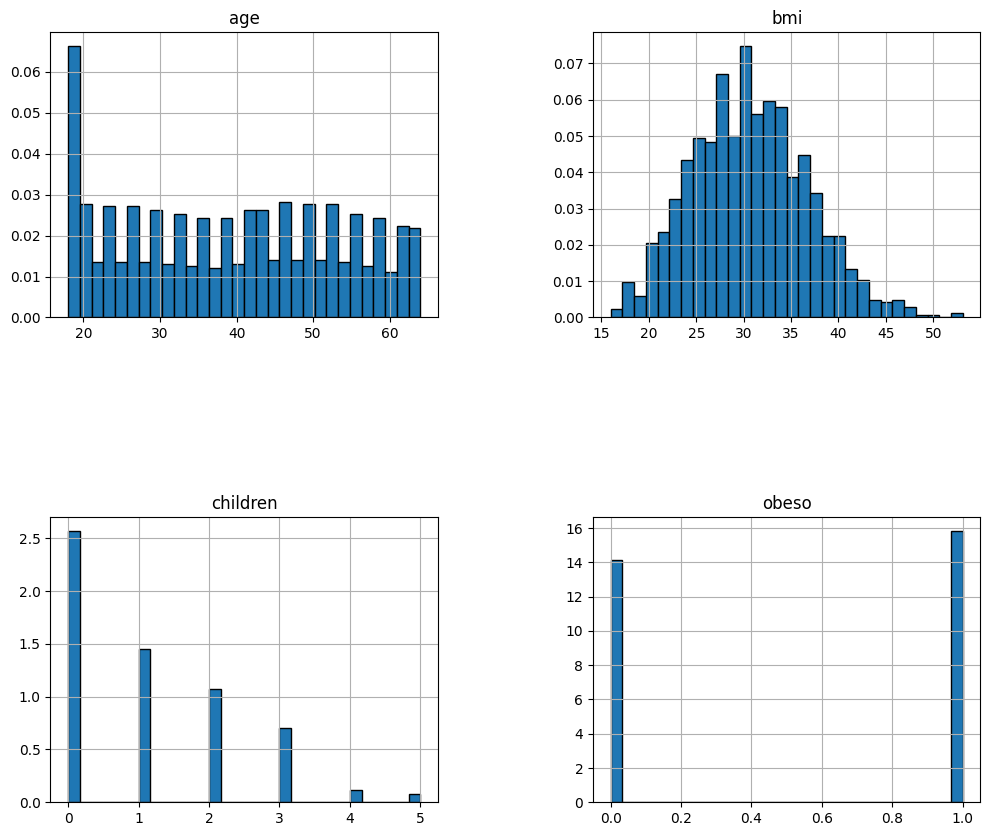

In [ ]:
import matplotlib.pyplot as plt

# construimos una serie de histogramas mostrando la distribución de las features
X_df.hist(figsize=(12, 10), bins=30, edgecolor="black", density=True)
plt.subplots_adjust(hspace=0.7, wspace=0.4)

También podríamos hacer lo mismo para la variable objetivo:

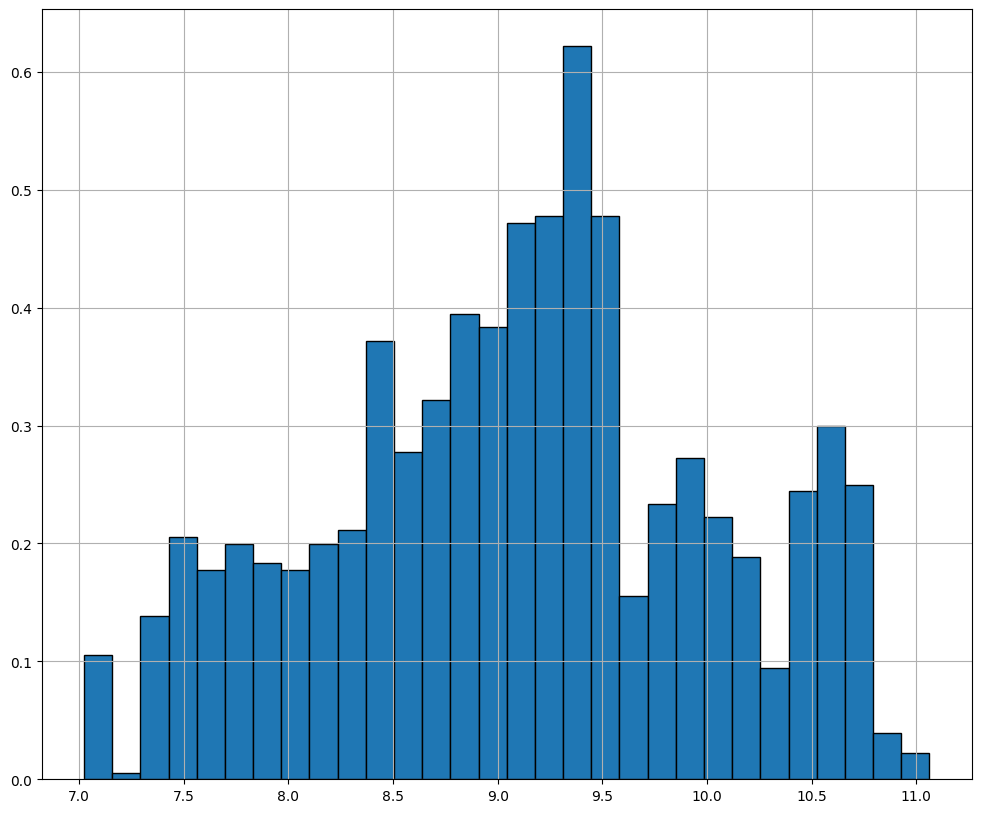

In [ ]:
# construimos una serie de histogramas mostrando la distribución de las features
y_df.hist(figsize=(12, 10), bins=30, edgecolor="black", density=True)
plt.subplots_adjust(hspace=0.7, wspace=0.4)

#### 4.3. Análisis de correlación entre variables

Vamos a calcular la matriz:

In [ ]:
# calculamos las correlaciones entre features e imprimimos la matriz
num_cols = ['age', 'bmi', 'children', 'obeso']

correlation_matrix = X_df[num_cols].corr()
correlation_matrix

,age,bmi,children,obeso
age,1.000000,0.109344,0.041536,0.086781
bmi,0.109344,1.000000,0.012755,0.799486
children,0.041536,0.012755,1.000000,0.010455
obeso,0.086781,0.799486,0.010455,1.000000


**Conclusion**  Correlacion alta entre bmi y obeso. Tiene sentido porque obeso se derivó directamente del bmi (BMI ≥ 30). Esto es multicolinealidad: las dos variables dicen básicamente lo mismo. Tener ambas en el modelo es redundante. Vamos a tener en cuenta cual de la dos utlizar para los distintos modelos a aplicar.

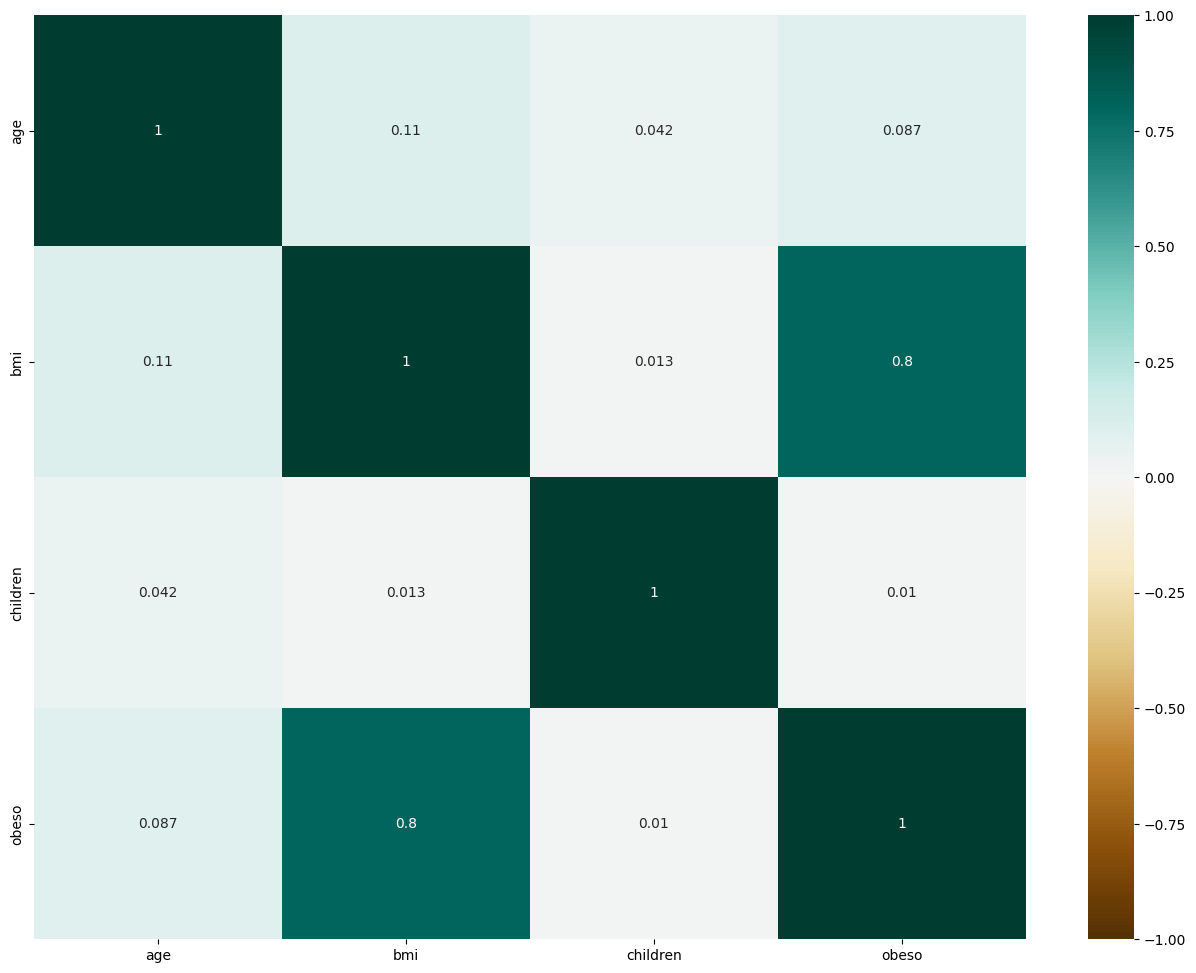

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# imprimimos la matriz como un heatmap
plt.figure(figsize=(16,12));
sns.heatmap(correlation_matrix, vmin=-1.0, vmax=1.0, center=0.0, annot=True, cmap='BrBG');

**Conclusion** igual a la anterior El único problema es bmi y obeso = 0.8
Todo lo demás es independiente  No hay valores negativos — la escala llega hasta -1.0 en naranja/marrón pero no aparece ese color en ningún par, lo que significa que ninguna variable tiene relación inversa con otra.

### 5. Análisis gráfico... pero en profundidad


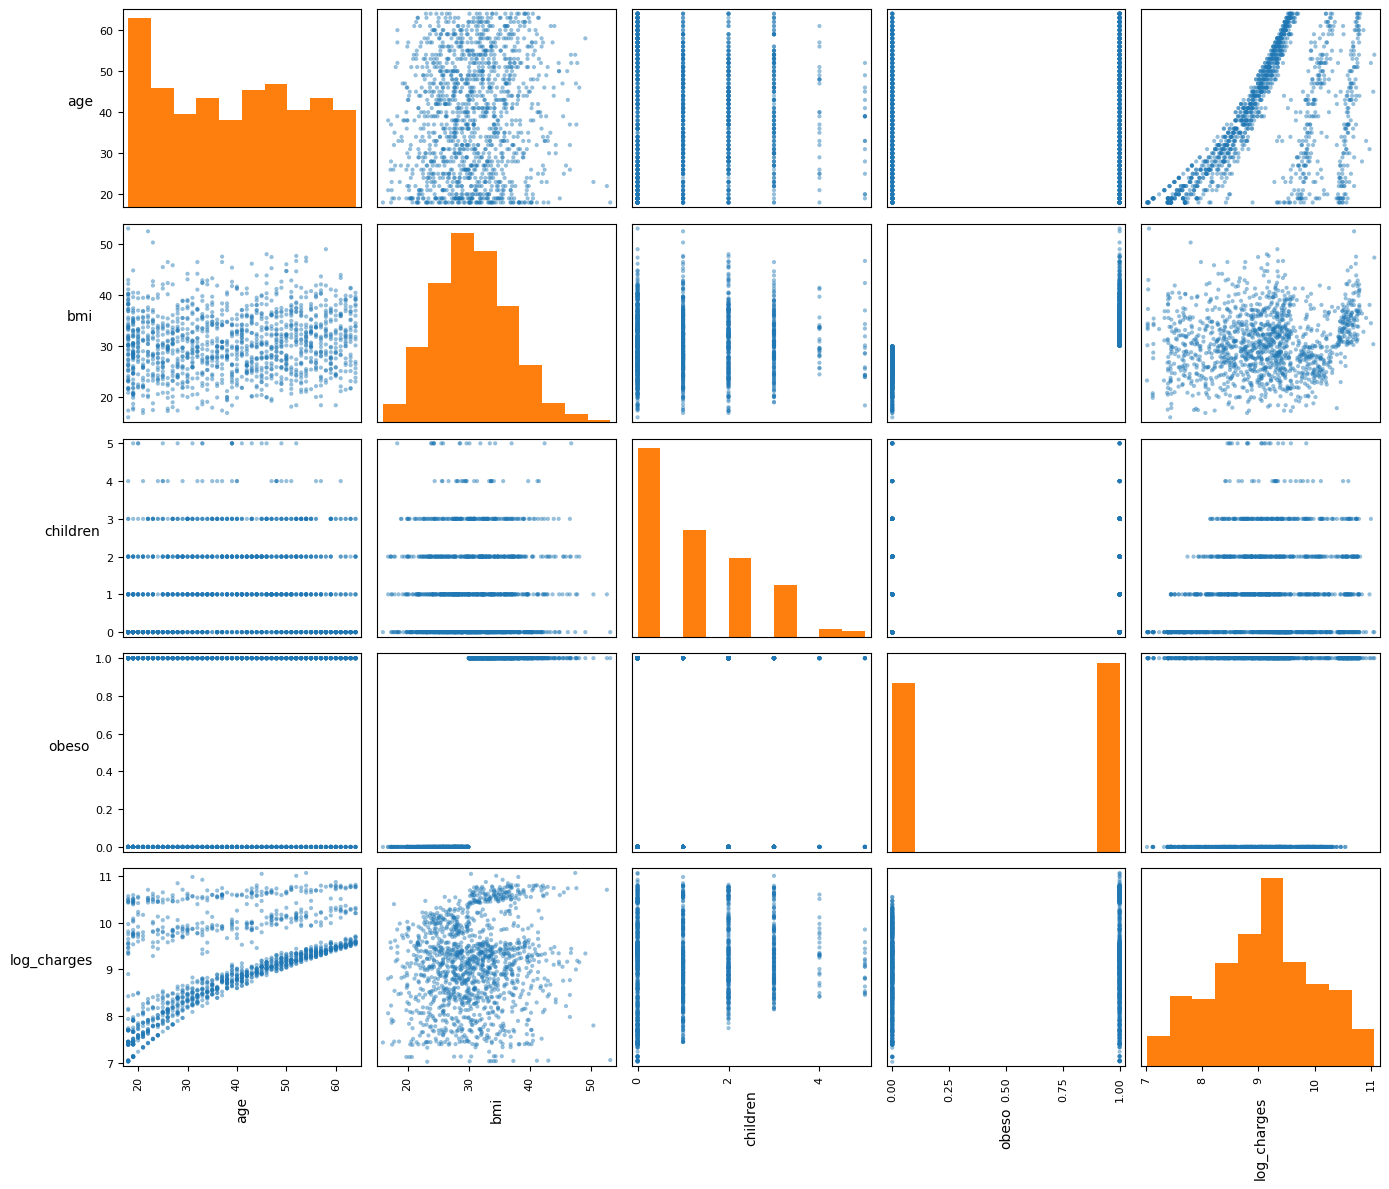

In [ ]:

from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt

# Numéricas + target
X_numeric_con_target = X_df[num_cols].copy()
X_numeric_con_target['log_charges'] = y_df

axs = scatter_matrix(X_numeric_con_target, figsize=(14, 12), alpha=0.47,
                     hist_kwds={'color':'#ff7f0e'})

for i in range(len(X_numeric_con_target.columns)):
    for j in range(len(X_numeric_con_target.columns)):
        ax = axs[i, j]
        ax.xaxis.label.set_rotation(90)
        ax.yaxis.label.set_rotation(0)
        ax.yaxis.label.set_ha('right')

plt.tight_layout()
plt.show()

Cambiamos el color de la diagonal para que se vea un poco mejor. Vemos que en la diagonal directamente tenemos representado el histograma con cómo se distribuyen las muestras en cada feature, y en los demás sectores tenemos un scatter plot contrastando una feature con otra. Con este tipo de gráficos es más fácil detectar entradas redundantes y relaciones entre features.

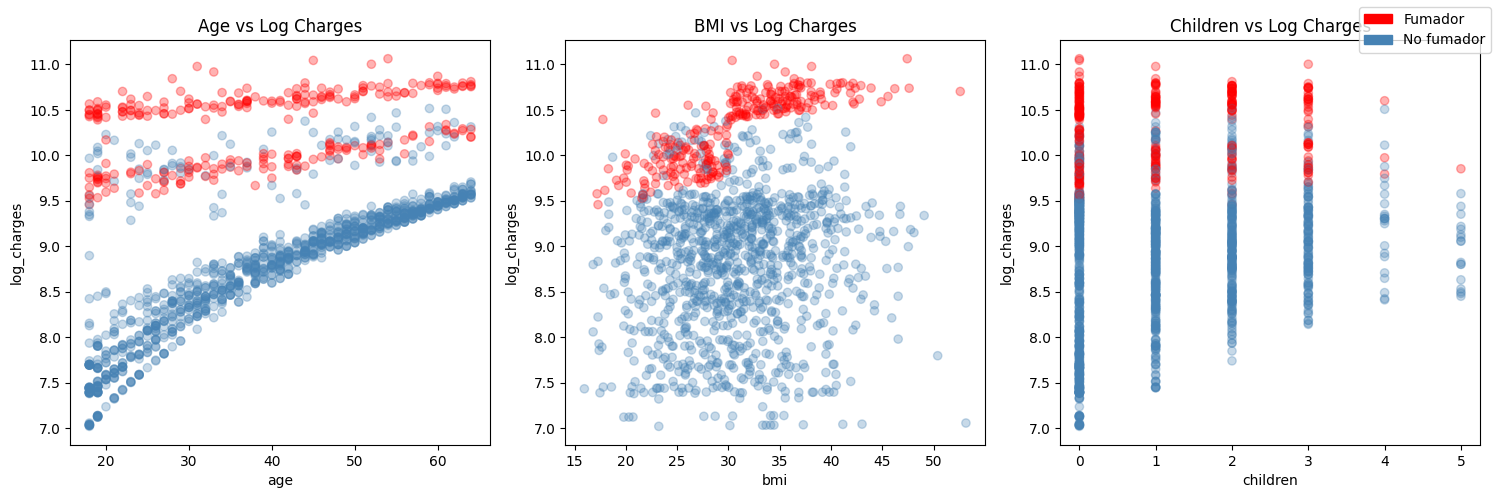

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colores = X_df['smoker'].map({'yes': 'red', 'no': 'steelblue'})

# age vs log_charges
axes[0].scatter(X_df['age'], y_df, c=colores, alpha=0.3)
axes[0].set_xlabel('age')
axes[0].set_ylabel('log_charges')
axes[0].set_title('Age vs Log Charges')

# bmi vs log_charges
axes[1].scatter(X_df['bmi'], y_df, c=colores, alpha=0.3)
axes[1].set_xlabel('bmi')
axes[1].set_ylabel('log_charges')
axes[1].set_title('BMI vs Log Charges')

# children vs log_charges
axes[2].scatter(X_df['children'], y_df, c=colores, alpha=0.3)
axes[2].set_xlabel('children')
axes[2].set_ylabel('log_charges')
axes[2].set_title('Children vs Log Charges')

# Leyenda
from matplotlib.patches import Patch
legend = [Patch(color='red', label='Fumador'), Patch(color='steelblue', label='No fumador')]
fig.legend(handles=legend, loc='upper right')

plt.tight_layout()
plt.show()

### 6. Particionar los datos


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

# Semilla
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Nota sobre identificadores
print("""
Nota: el dataset de seguros no tiene identificadores únicos por persona.
No podemos verificar si dos filas corresponden al mismo asegurado
con mediciones distintas. Asumimos que cada fila es un asegurado diferente.
""")

# Particionado 70/30
# Primero separamos 70% train+validation y 30% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_df, y_df,
    test_size=0.30,
    random_state=SEED
)

# Luego del 70% separamos 70% train y 30% validation
# → 70% × 70% = 49% train
# → 70% × 30% = 21% validation
# → 30% test
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.30,
    random_state=SEED
)

# Verificar particiones
total = len(X_df)
print("=== Particionado de datos ===")
print(f"Total muestras:     {total:5d} (100%)")
print(f"Train:              {len(X_train):5d} ({len(X_train)/total*100:.1f}%)")
print(f"Validation:         {len(X_val):5d} ({len(X_val)/total*100:.1f}%)")
print(f"Test:               {len(X_test):5d} ({len(X_test)/total*100:.1f}%)")
print(f"\nSuma train+val+test: {len(X_train)+len(X_val)+len(X_test)}")

# Verificar distribución del target en cada set
print("\n=== Distribución de log_charges por set ===")
print(f"{'Set':12} {'Media':10} {'Std':10} {'Min':10} {'Max':10}")
print("-" * 52)
for nombre, y in [('Train', y_train), ('Validation', y_val), ('Test', y_test)]:
    print(f"{nombre:12} {y.mean():10.3f} {y.std():10.3f} {y.min():10.3f} {y.max():10.3f}")


Nota: el dataset de seguros no tiene identificadores únicos por persona.
No podemos verificar si dos filas corresponden al mismo asegurado
con mediciones distintas. Asumimos que cada fila es un asegurado diferente.

=== Particionado de datos ===
Total muestras:      1337 (100%)
Train:                654 (48.9%)
Validation:           281 (21.0%)
Test:                 402 (30.1%)

Suma train+val+test: 1337

=== Distribución de log_charges por set ===
Set          Media      Std        Min        Max       
----------------------------------------------------
Train             9.096      0.913      7.023     10.978
Validation        9.077      0.906      7.036     10.793
Test              9.122      0.939      7.031     11.063


In [ ]:
print("X_df shape:", X_df.shape)
print("X_df columnas:", X_df.columns.tolist())
print("\nX_train shape:", X_train.shape)
print("X_val shape:  ", X_val.shape)
print("X_test shape: ", X_test.shape)

X_df shape: (1337, 7)
X_df columnas: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'obeso']

X_train shape: (654, 7)
X_val shape:   (281, 7)
X_test shape:  (402, 7)



Para comparar las distribuciones vamos a utilizar un histograma.

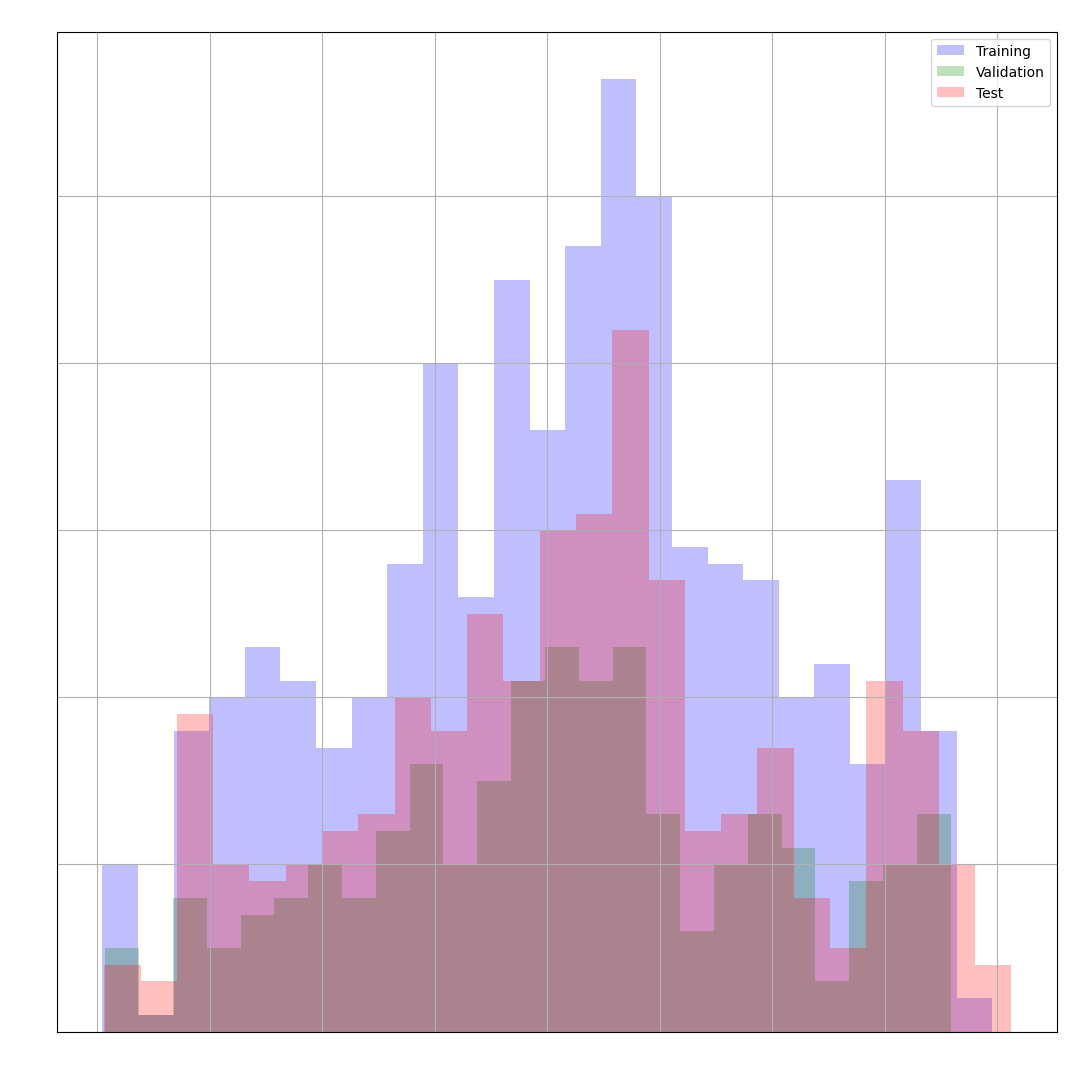

In [ ]:
from matplotlib import pyplot as plt

relative_frequency = False
n_bins = 25

# creamos el canvas de la figura
fig=plt.figure(figsize=(10,10))
# agregamos los ejes
ax=fig.add_axes([0,0,1,1])
# hacemos histogramas de 50 baldes para los datos de entrenamiento, validación y
# test, en los colores azul (b), verde (g) y rojo (r), con cierta transparencia
# alpha
ax.hist(y_train, n_bins, density=relative_frequency, facecolor='b', alpha=0.25)
ax.hist(y_val, n_bins, density=relative_frequency, facecolor='g', alpha=0.25)
ax.hist(y_test, n_bins, density=relative_frequency, facecolor='r', alpha=0.25)
# agregamos las etiquetas de los ejes x e y
ax.set_xlabel('log_charges', color='white')
if relative_frequency:
  ax.set_ylabel('Relative Frequency', color='white')
else:
  ax.set_ylabel('Absolute Frequency', color='white')

ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

# le colocamos un título
ax.set_title(
    'Histograms of y - Training, validation and test set',
    color='white'
    )
# agregamos la leyenda
ax.legend(['Training', 'Validation', 'Test'])
ax.grid(True)
# lo mostramos por pantalla
plt.show()

Los 3 histogramas siguen el mismo patron el particionado aleatorio fue correcto, no introdujo sesgo. Los tres sets tienen representación similar de fumadores y no fumadores.

### 7. Normalización y estandarización de los datos



In [ ]:
print('Training set statistics:')
print('Min values: {}'.format(np.min(X_train, axis=0)))
print('Max values: {}'.format(np.max(X_train, axis=0)))

print('=== Comparación de rangos entre sets ===')
for col in ['age', 'bmi', 'children', 'obeso']:
    train_min = X_train[col].min()
    train_max = X_train[col].max()
    val_min   = X_val[col].min()
    val_max   = X_val[col].max()
    test_min  = X_test[col].min()
    test_max  = X_test[col].max()
    print(f"{col:10} Train:[{train_min:.1f}-{train_max:.1f}]  "
          f"Val:[{val_min:.1f}-{val_max:.1f}]  "
          f"Test:[{test_min:.1f}-{test_max:.1f}]")

Training set statistics:
Min values: age                18
sex            female
bmi             15.96
children            0
smoker             no
region      northeast
obeso               0
dtype: object
Max values: age                64
sex              male
bmi             53.13
children            5
smoker            yes
region      southwest
obeso               1
dtype: object
=== Comparación de rangos entre sets ===
age        Train:[18.0-64.0]  Val:[18.0-64.0]  Test:[18.0-64.0]
bmi        Train:[16.0-53.1]  Val:[17.3-52.6]  Test:[16.8-48.1]
children   Train:[0.0-5.0]  Val:[0.0-5.0]  Test:[0.0-5.0]
obeso      Train:[0.0-1.0]  Val:[0.0-1.0]  Test:[0.0-1.0]


Los rangos son consistentes entre los tres sets. Las pequeñas diferencias en bmi (val máx=49.1 vs train máx=53.1) y children (val máx=4 vs train máx=5) son esperables, no representan un sesgo significativo. El dataset está correctamente dividido para seguir con el entrenamiento.

Vamos a ver distancias graficamente entre 3 muestras:
- 1. Joven con BMI=16.8
- 2. Joven con caracteristicas similares al primero
- 3. Anciano con BMI=53.1

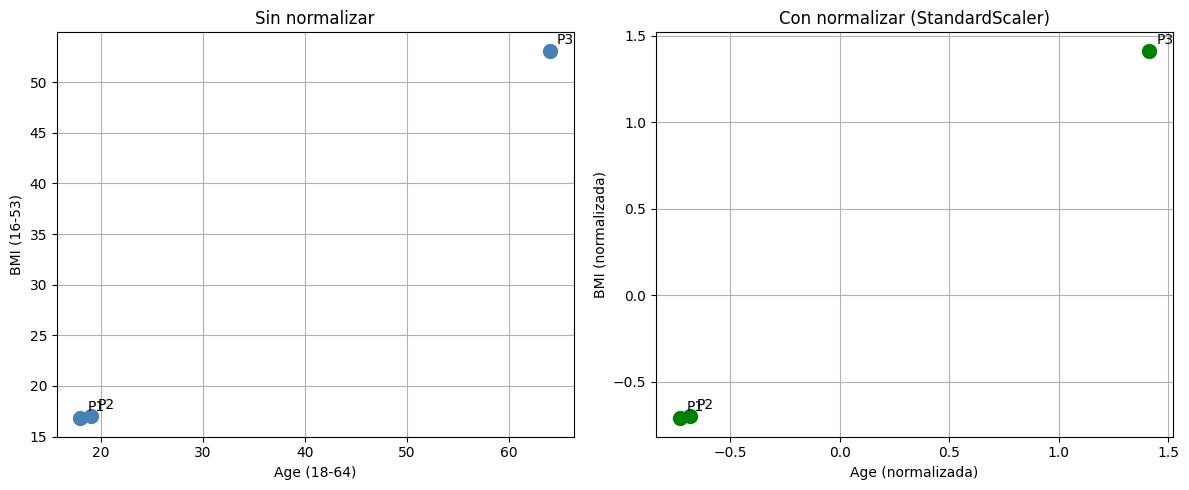

=== Distancias euclidianas SIN normalizar ===
      P1         P2         P3        
P1          0.00       1.02      58.60
P2          1.02       0.00      57.69
P3         58.60      57.69       0.00

=== Distancias euclidianas CON normalizar ===
      P1         P2         P3        
P1          0.00       0.05       3.02
P2          0.05       0.00       2.98
P3          3.02       2.98       0.00

=== Interpretación ===
Sin normalizar: la distancia P1-P2 está dominada por BMI
Con normalizar: age y BMI contribuyen por igual a la distancia



In [ ]:
from scipy.spatial.distance import pdist, squareform
import numpy as np
import matplotlib.pyplot as plt

# Probamos con 3 asegurados
#   age   bmi
samples_raw = np.array([
    [18,  16.8],   # asegurado 1 - joven, bajo peso
    [19,  17.0],   # asegurado 2 - similar al 1
    [64,  53.1],   # asegurado 3 - mayor, obesidad severa
])

# Sin normalizar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(samples_raw[:,0], samples_raw[:,1], s=100, color='steelblue')
for i, (age, bmi) in enumerate(samples_raw):
    ax1.annotate(f'P{i+1}', (age, bmi), textcoords='offset points', xytext=(5,5))
ax1.grid(True)
ax1.set_xlabel('Age (18-64)')
ax1.set_ylabel('BMI (16-53)')
ax1.set_title('Sin normalizar')

#  Con normalizar
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
samples_scaled = scaler.fit_transform(samples_raw)

ax2.scatter(samples_scaled[:,0], samples_scaled[:,1], s=100, color='green')
for i, (age, bmi) in enumerate(samples_scaled):
    ax2.annotate(f'P{i+1}', (age, bmi), textcoords='offset points', xytext=(5,5))
ax2.grid(True)
ax2.set_xlabel('Age (normalizada)')
ax2.set_ylabel('BMI (normalizada)')
ax2.set_title('Con normalizar (StandardScaler)')

plt.tight_layout()
plt.show()

#  Distancias sin normalizar
print("=== Distancias euclidianas SIN normalizar ===")
dist_raw = squareform(pdist(samples_raw, metric='euclidean'))
print(f"{'':5} {'P1':10} {'P2':10} {'P3':10}")
for i, row in enumerate(dist_raw):
    print(f"P{i+1}    {row[0]:10.2f} {row[1]:10.2f} {row[2]:10.2f}")

#  Distancias con normalizar
print("\n=== Distancias euclidianas CON normalizar ===")
dist_scaled = squareform(pdist(samples_scaled, metric='euclidean'))
print(f"{'':5} {'P1':10} {'P2':10} {'P3':10}")
for i, row in enumerate(dist_scaled):
    print(f"P{i+1}    {row[0]:10.2f} {row[1]:10.2f} {row[2]:10.2f}")

print("""
=== Interpretación ===
Sin normalizar: la distancia P1-P2 está dominada por BMI
Con normalizar: age y BMI contribuyen por igual a la distancia
""")

Sin normalizar la distancia euclidiana entre dos asegurados similares
(P1: age=18, bmi=16.8 y P2: age=19, bmi=17.0) es 1.02, dominada
por la variable BMI que tiene mayor rango numérico. La diferencia
de 1 año de edad queda prácticamente ignorada.

Con StandardScaler la distancia se reduce a 0.05, reflejando
correctamente que P1 y P2 son asegurados casi idénticos.
Esto justifica el uso obligatorio de normalización en
Linear Regression donde la escala afecta directamente
los coeficientes del modelo.

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import pickle
from os import path

# columnas
num_cols = ['age', 'bmi', 'children', 'obeso']
cat_cols = ['sex', 'smoker', 'region']

# Pipeline con ColumnTransformer
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'))
])

pipeline = ColumnTransformer([
    ('num', numeric_pipeline, num_cols),
    ('cat', categorical_pipeline, cat_cols)
])

#  Ajustar en train y transformar
X_train_stand = pipeline.fit_transform(X_train)  # fit + transform
X_val_stand   = pipeline.transform(X_val)         # solo transform
X_test_stand  = pipeline.transform(X_test)        # solo transform

#  Verificar media ≈ 0 y std ≈ 1 en columnas numéricas
print('X_train_stand shape:', X_train_stand.shape)
print('Mean numéricas:', X_train_stand[:, :4].mean(axis=0).round(4))
print('Std  numéricas:', X_train_stand[:, :4].std(axis=0).round(4))

#  Guardar
save_path = path.join(datasets_folder, 'insurance.pkl')
print(f'\nGuardando {save_path}')
with open(save_path, 'wb') as f:
    partitioned_dataset = {
        'X_train':        X_train_stand,
        'X_val':          X_val_stand,
        'X_test':         X_test_stand,
        'y_train':        y_train,
        'y_val':          y_val,
        'y_test':         y_test,
        'feature_labels': feature_labels,
        'pipeline':       pipeline,
    }
    pickle.dump(partitioned_dataset, f)

print(' Guardado correctamente')

X_train_stand shape: (654, 9)
Mean numéricas: [ 0. -0. -0.  0.]
Std  numéricas: [1. 1. 1. 1.]

Guardando data/insurance.pkl
 Guardado correctamente


### 8. Reducción de dimensionalidad


#### 8.1. Principal Component Analysis (PCA)
 A continuación aplicaremos PCA sobre todas nuestras features para mapear los datos de entrenamiento a un espacio 2D

=== Varianza explicada por componente ===
Componente   Varianza     Acumulada   
--------------------------------------
PC 1               0.3705       0.3705
PC 2               0.2109       0.5814
PC 3               0.1852       0.7666
PC 4               0.0554       0.8220
PC 5               0.0507       0.8727
PC 6               0.0492       0.9219
PC 7               0.0356       0.9574
PC 8               0.0309       0.9883
PC 9               0.0117       1.0000


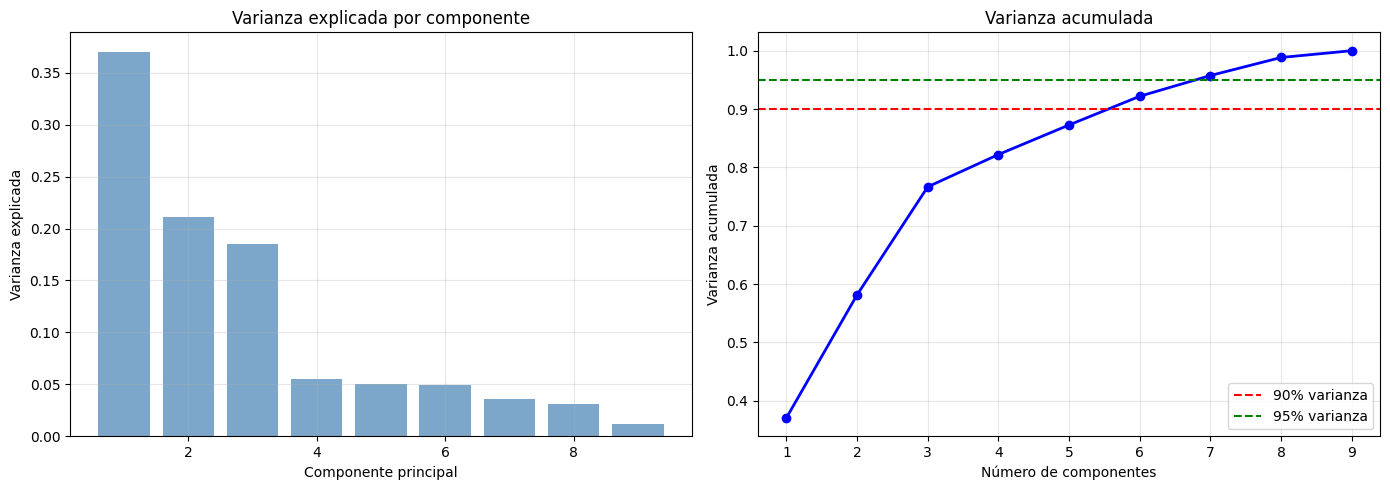

Componentes para explicar 90% varianza: 6
Componentes para explicar 95% varianza: 7
Componentes para explicar 99% varianza: 9


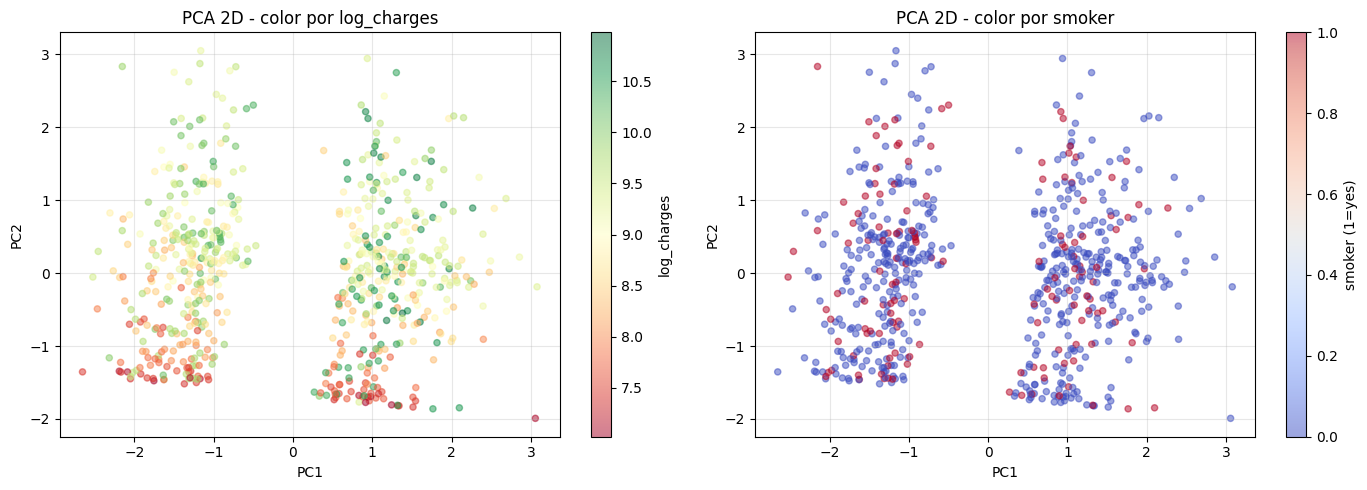

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

#  PCA
# Primero necesitamos X_train_stand como array numpy
# ya lo tenemos del pipeline de estandarización

# PCA sobre el training set estandarizado
pca = PCA()
pca.fit(X_train_stand)

# Varianza
varianza_explicada     = pca.explained_variance_ratio_
varianza_acumulada     = np.cumsum(varianza_explicada)

print("=== Varianza explicada por componente ===")
print(f"{'Componente':12} {'Varianza':12} {'Acumulada':12}")
print("-" * 38)
for i, (var, acum) in enumerate(zip(varianza_explicada, varianza_acumulada)):
    print(f"PC{i+1:2d}         {var:12.4f} {acum:12.4f}")

#  Gráfico varianza acumulada
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Varianza por componente
ax1.bar(range(1, len(varianza_explicada)+1), varianza_explicada,
        color='steelblue', alpha=0.7)
ax1.set_xlabel('Componente principal')
ax1.set_ylabel('Varianza explicada')
ax1.set_title('Varianza explicada por componente')
ax1.grid(True, alpha=0.3)

# Varianza acumulada
ax2.plot(range(1, len(varianza_acumulada)+1), varianza_acumulada,
         'bo-', linewidth=2)
ax2.axhline(y=0.90, color='r', linestyle='--', label='90% varianza')
ax2.axhline(y=0.95, color='g', linestyle='--', label='95% varianza')
ax2.set_xlabel('Número de componentes')
ax2.set_ylabel('Varianza acumulada')
ax2.set_title('Varianza acumulada')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Cuántos componentes neesitamos
for umbral in [0.90, 0.95, 0.99]:
    n = np.argmax(varianza_acumulada >= umbral) + 1
    print(f"Componentes para explicar {umbral*100:.0f}% varianza: {n}")

# Proyección 2D coloreada por log_charges ─────────────────
pca_2d = PCA(n_components=2)
X_train_pca = pca_2d.fit_transform(X_train_stand)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Color por log_charges
sc1 = ax1.scatter(X_train_pca[:, 0], X_train_pca[:, 1],
                  c=y_train, cmap='RdYlGn', alpha=0.5, s=20)
plt.colorbar(sc1, ax=ax1, label='log_charges')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_title('PCA 2D - color por log_charges')
ax1.grid(True, alpha=0.3)

# Color por smoker
smoker_encoded = (X_train['smoker'] == 'yes').values
sc2 = ax2.scatter(X_train_pca[:, 0], X_train_pca[:, 1],
                  c=smoker_encoded, cmap='coolwarm', alpha=0.5, s=20)
plt.colorbar(sc2, ax=ax2, label='smoker (1=yes)')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_title('PCA 2D - color por smoker')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Conclusión**: PCA muestra que se necesitan 6 componentes para explicar
el 90% de la varianza del dataset, lo que indica que la información está distribuida entre múltiples features sin una dominancia clara de una sola variable en el espacio transformado.

La proyección 2D muestra una separación parcial por nivel de cuota (log_charges) a lo largo de PC1, pero la separación entre fumadores y no fumadores no es completamente visible en solo 2 dimensiones. Esto explica por qué los modelos de regresión necesitan más de 2 features para obtener buenos resultados (R² ~0.83).

Los últimos 3 componentes con varianza cercana a 0 corresponden a columnas redundantes generadas por OneHotEncoder, confirmando que el preprocesamiento fue correcto.

#### 8.2. t-distributed Stochastic Neighbor Embedding (t-SNE)


Shape t-SNE: (654, 2)


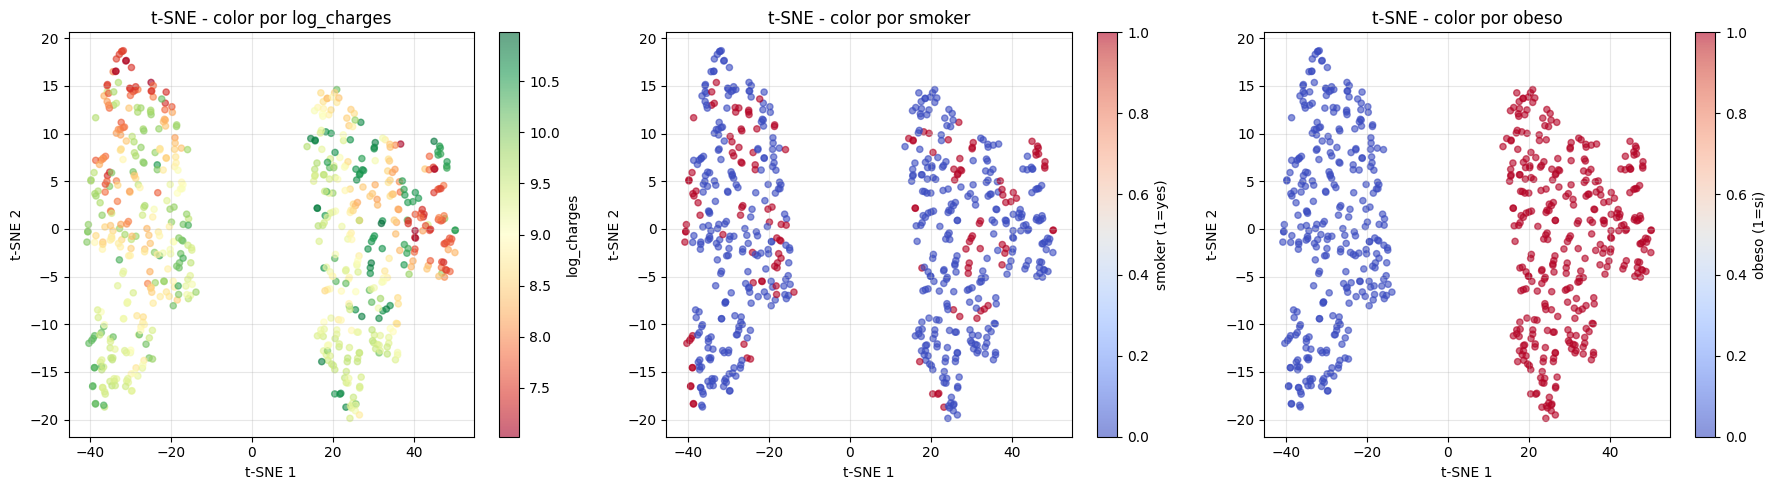

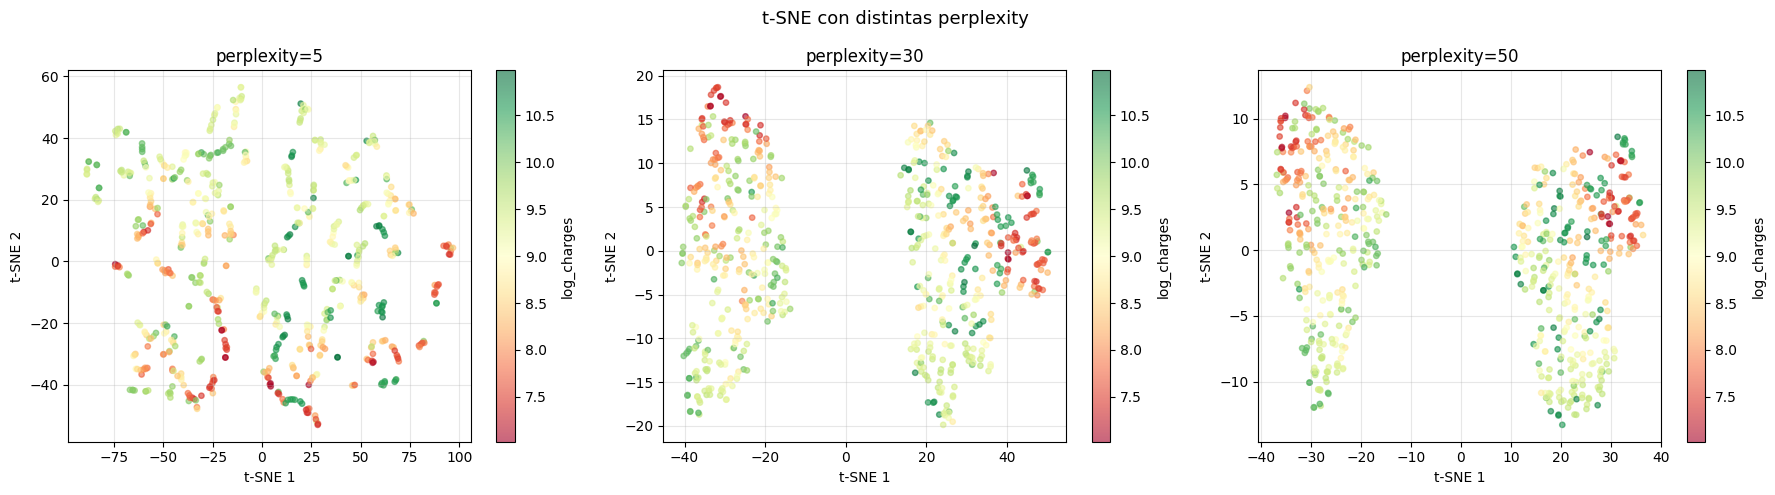

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

#SEED=42

# Aplicar t-SNE ───────────────────────────────────────────
# t-SNE es más lento que PCA, reduce siempre a 2D para visualizar
# perplexity controla el balance entre estructura local y global
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
X_train_tsne = tsne.fit_transform(X_train_stand)

print("Shape t-SNE:", X_train_tsne.shape)

# Proyección coloreada por log_charges
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Color por log_charges
sc1 = axes[0].scatter(X_train_tsne[:, 0], X_train_tsne[:, 1],
                      c=y_train, cmap='RdYlGn', alpha=0.6, s=20)
plt.colorbar(sc1, ax=axes[0], label='log_charges')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')
axes[0].set_title('t-SNE - color por log_charges')
axes[0].grid(True, alpha=0.3)

# Color por smoker
smoker_encoded = (X_train['smoker'] == 'yes').values
sc2 = axes[1].scatter(X_train_tsne[:, 0], X_train_tsne[:, 1],
                      c=smoker_encoded, cmap='coolwarm', alpha=0.6, s=20)
plt.colorbar(sc2, ax=axes[1], label='smoker (1=yes)')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].set_title('t-SNE - color por smoker')
axes[1].grid(True, alpha=0.3)

# Color por obeso
sc3 = axes[2].scatter(X_train_tsne[:, 0], X_train_tsne[:, 1],
                      c=X_train['obeso'].values, cmap='coolwarm', alpha=0.6, s=20)
plt.colorbar(sc3, ax=axes[2], label='obeso (1=si)')
axes[2].set_xlabel('t-SNE 1')
axes[2].set_ylabel('t-SNE 2')
axes[2].set_title('t-SNE - color por obeso')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── 3. Comparar distintas perplexity ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('t-SNE con distintas perplexity', fontsize=13)

for ax, perp in zip(axes, [5, 30, 50]):
    tsne_p = TSNE(n_components=2, random_state=SEED, perplexity=perp)
    X_p = tsne_p.fit_transform(X_train_stand)
    sc = ax.scatter(X_p[:, 0], X_p[:, 1],
                    c=y_train, cmap='RdYlGn', alpha=0.6, s=15)
    plt.colorbar(sc, ax=ax, label='log_charges')
    ax.set_title(f'perplexity={perp}')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Conclusión**: El dataset se divide naturalmente en dos grupos principales determinados por la variable smoker`.

El grupo izquierdo concentra a los no fumadores con cuotas bajas (log_charges ~7.5-9.0) y el grupo derecho a los fumadores con cuotas altas (log_charges ~9.5-11.0). Esta separación es prácticamente perfecta, confirmando que smoker es la feature más predictiva del modelo.

La variable obeso no genera grupos independientes pero introduce variación dentro de cada grupo, explicando por qué también es relevante para el modelo.

A diferencia de PCA, t-SNE captura estas relaciones no lineales en solo 2 dimensiones gracias a su algoritmo de preservación de vecindad local. La perplexity=30 resultó la más adecuada para este dataset de 654 muestras de entrenamiento.

# 9 - Aplicando algoritmos

Vamos a aplicar tres algoritmos Linear Regression, Random Forest y XGBoost

Entrenar y evaluar en Train/Validation
El Modelo APRENDE y se ajusta
- fit() sobre X_train
- predict() sobre X_train y X_val
- Compara Train vs Val para detectar overfitting
- Semilla fija para reproducibilidad

In [ ]:
#import numpy as np
#import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor


print(f"Semilla fijada: {SEED}")

# Definir columnas
num_cols = ['age', 'bmi', 'children', 'obeso']
cat_cols = ['sex', 'smoker', 'region']

# Pipelines de preprocesamiento

# Linear → CON StandardScaler
# Reemplaza valores faltantes con la mediana
numeric_pipeline_linear = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# Árboles → SIN StandardScaler
# Reemplaza valores faltantes con la mediana
numeric_pipeline_tree = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

# Categóricas → igual para todos
# -- Reemplaza valores faltantes por el valor mas frecuente
# -- OneHotEncoding sin devolver matrix sparse
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ColumnTransformers diferenciados entre numericos y categoricos.
preprocessor_linear = ColumnTransformer([
    ('num', numeric_pipeline_linear, num_cols),
    ('cat', categorical_pipeline,    cat_cols)
])

preprocessor_tree = ColumnTransformer([
    ('num', numeric_pipeline_tree, num_cols),
    ('cat', categorical_pipeline,  cat_cols)
])

# modelos
# linear regression
pipeline_lr = Pipeline([
    ('preprocessor', preprocessor_linear),
    ('modelo', LinearRegression())
])

# random forest
pipeline_rf = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('modelo', RandomForestRegressor(n_estimators=100, random_state=SEED))
])

# XGBoost
pipeline_xgb = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('modelo', XGBRegressor(n_estimators=100, random_state=SEED, verbosity=0))
])

# Función de evaluación
def evaluar_modelo(nombre, modelo, X_tr, y_tr, X_v, y_v):
    modelo.fit(X_tr, y_tr)
    y_pred_train = modelo.predict(X_tr)
    y_pred_val   = modelo.predict(X_v)

    print(f"\n{'='*50}")
    print(f"  {nombre}")
    print(f"{'='*50}")
    print(f"{'Métrica':8} {'Train':12} {'Validation':12}")
    print(f"{'-'*35}")

    for metrica, fn in [
        ('MAE',  mean_absolute_error),
        ('RMSE', lambda a,b: np.sqrt(mean_squared_error(a,b))),
        ('R²',   r2_score)
    ]:
        tr  = fn(y_tr, y_pred_train)
        val = fn(y_v,  y_pred_val)

         # Solo marcar overfit en modelos con alta capacidad (árboles)
        es_modelo_complejo = 'Forest' in nombre or 'XGB' in nombre or 'Boost' in nombre
        ovf = " overfit" if (tr - val) > 0.05 and metrica == 'R²' and es_modelo_complejo else ""

        #ovf = " overfit" if (tr - val) > 0.05 and metrica == 'R²' else ""
        print(f"{metrica:8} {tr:12.4f} {val:12.4f}  {ovf}")

    return modelo

# Entrenar y evaluar en Train/Validation
print("Entrenando modelos...")
modelo_lr  = evaluar_modelo('Linear Regression', pipeline_lr,
                             X_train, y_train, X_val, y_val)
modelo_rf  = evaluar_modelo('Random Forest',     pipeline_rf,
                             X_train, y_train, X_val, y_val)
modelo_xgb = evaluar_modelo('XGBoost',           pipeline_xgb,
                             X_train, y_train, X_val, y_val)



# comparativa ────────────────────────────────────────
print(f"\n{'='*55}")
print("  COMPARACIÓN FINAL EN VALIDATION SET")
print(f"{'='*55}")
print(f"{'Modelo':22} {'MAE':10} {'RMSE':10} {'R²':10}")
print(f"{'-'*55}")

resultados = []
for nombre, modelo in [('Linear Regression', modelo_lr),
                        ('Random Forest',     modelo_rf),
                        ('XGBoost',           modelo_xgb)]:
    y_pred = modelo.predict(X_val)
    mae  = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    r2   = r2_score(y_val, y_pred)
    print(f"{nombre:22} {mae:10.4f} {rmse:10.4f} {r2:10.4f}")
    resultados.append({'Modelo': nombre, 'MAE': mae, 'RMSE': rmse, 'R²': r2})

# Mejor modelo
df_resultados = pd.DataFrame(resultados)
mejor = df_resultados.loc[df_resultados['R²'].idxmax(), 'Modelo']
print(f"\n Mejor modelo por R²: {mejor}")





Semilla fijada: 42
Entrenando modelos...

  Linear Regression
Métrica  Train        Validation  
-----------------------------------
MAE            0.2741       0.3051  
RMSE           0.4292       0.4917  
R²             0.7785       0.7042  

  Random Forest
Métrica  Train        Validation  
-----------------------------------
MAE            0.0735       0.2155  
RMSE           0.1454       0.4312  
R²             0.9746       0.7725   overfit

  XGBoost
Métrica  Train        Validation  
-----------------------------------
MAE            0.0175       0.2422  
RMSE           0.0276       0.4642  
R²             0.9991       0.7364   overfit

  COMPARACIÓN FINAL EN VALIDATION SET
Modelo                 MAE        RMSE       R²        
-------------------------------------------------------
Linear Regression          0.3051     0.4917     0.7042
Random Forest              0.2155     0.4312     0.7725
XGBoost                    0.2422     0.4642     0.7364

 Mejor modelo por R²: Random

De estos resultados se puede intuir que el modelo de Linear Regression tiene capacidad limitada para capturar relaciones no lineales del dataset.

LR no overfittea, pero si se ve un claro overfitting en los modelos RF y XGBoost.

Vamos a explorar y evaluar un poco mas los modelos lineales. Ridge vs Linear Regression

In [ ]:
from sklearn.model_selection import KFold, cross_val_score

kfold = KFold(n_splits=5, shuffle=True, random_state=SEED)

scores_lr = cross_val_score(pipeline_lr, X_train, y_train, cv=kfold, scoring='r2')
print(f"Linear Regression CV R²: {scores_lr.mean():.4f} ± {scores_lr.std():.4f}")
print(f"Por fold: {scores_lr.round(4)}")

Linear Regression CV R²: 0.7691 ± 0.0352
Por fold: [0.764 0.807 0.704 0.789 0.78 ]



  Ridge Regression
Métrica  Train        Validation  
-----------------------------------
MAE            0.2742       0.3053  
RMSE           0.4292       0.4917  
R²             0.7785       0.7043  

=== Linear Regression vs Ridge ===
Linear Regression    R² Test = 0.7899
Ridge (alpha=1.0)    R² Test = 0.7898

=== Ridge con distintos alpha ===
alpha=    0.01  R² Test = 0.7899
alpha=    0.10  R² Test = 0.7899
alpha=    1.00  R² Test = 0.7898
alpha=   10.00  R² Test = 0.7878
alpha=  100.00  R² Test = 0.7299
MSE en validation = 0.2417
MAE en validation = 0.3053
Coeficientes: [ 0.498  0.027  0.111  0.064  0.043 -0.043 -0.764  0.764  0.063  0.051
 -0.055 -0.059]
Cantidad de coeficientes: 12
Feature names: ['age', 'bmi', 'children', 'obeso', 'sex_female', 'sex_male', 'smoker_no', 'smoker_yes', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']
Cantidad de features: 12


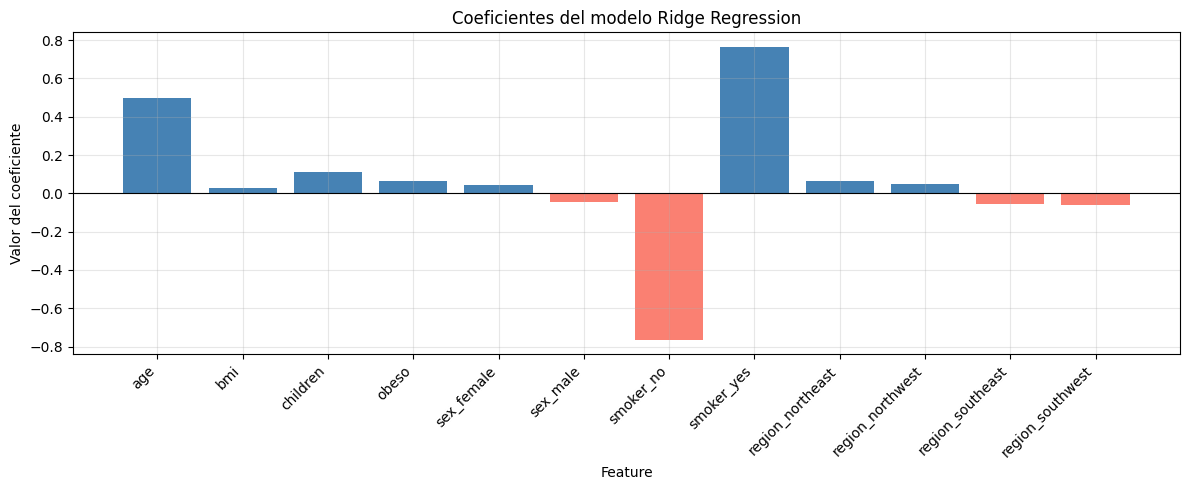


=== Coeficientes ordenados por magnitud ===
smoker_no                 - 0.7639
smoker_yes                + 0.7639
age                       + 0.4976
children                  + 0.1112
obeso                     + 0.0641
region_northeast          + 0.0632
region_southwest          - 0.0590
region_southeast          - 0.0553
region_northwest          + 0.0511
sex_male                  - 0.0431
sex_female                + 0.0431
bmi                       + 0.0266

=== Grid Search - Ridge alpha ===
alpha =      0.00001  -  MSE = 0.24180
alpha =      0.00010  -  MSE = 0.24180
alpha =      0.00100  -  MSE = 0.24180
alpha =      0.01000  -  MSE = 0.24180
alpha =      0.10000  -  MSE = 0.24179
alpha =      1.00000  -  MSE = 0.24173
alpha =     10.00000  -  MSE = 0.24193
alpha =    100.00000  -  MSE = 0.27981
alpha =   1000.00000  -  MSE = 0.55924
alpha =  10000.00000  -  MSE = 0.77466
alpha = 100000.00000  -  MSE = 0.81317
alpha = 1000000.00000  -  MSE = 0.81735
Best alpha: 1.0
Best MSE on val

In [ ]:
# Ridge Regression
from sklearn.linear_model import Ridge

pipeline_ridge = Pipeline([
    ('preprocessor', preprocessor_linear),
    ('modelo', Ridge(alpha=1.0, random_state=SEED))
])

modelo_ridge = evaluar_modelo('Ridge Regression', pipeline_ridge,
                               X_train, y_train, X_val, y_val)

print("\n=== Linear Regression vs Ridge ===")
for nombre, modelo in [('Linear Regression', modelo_lr),
                        ('Ridge (alpha=1.0)', modelo_ridge)]:
    r2_test = r2_score(y_test, modelo.predict(X_test))
    print(f"{nombre:20} R² Test = {r2_test:.4f}")

print("\n=== Ridge con distintos alpha ===")
for alpha in [0.01, 0.1, 1.0, 10.0, 100.0]:
    pipe = Pipeline([
        ('preprocessor', preprocessor_linear),
        ('modelo', Ridge(alpha=alpha, random_state=SEED))
    ])
    pipe.fit(X_train, y_train)
    r2 = r2_score(y_test, pipe.predict(X_test))
    print(f"alpha={alpha:8.2f}  R² Test = {r2:.4f}")

def mse(y, y_hat):
  '''
  Función para calcular el error cuadrático medio
  '''
  y = np.squeeze(y)
  y_hat = np.squeeze(y_hat)
  # suma promedio de diferencias al cuadrado
  if y.shape != y_hat.shape:
    raise ValueError('y e y_hat tienen que tener el mismo tamaño')
  return (1 / y.size) * np.sum((y - y_hat)**2)


def mae(y, y_hat):
  '''
  Función para calcular el error absoluto medio
  '''
  # suma promedio de diferencias absolutas
  y = np.squeeze(y)
  y_hat = np.squeeze(y_hat)
  if y.shape != y_hat.shape:
    raise ValueError('y e y_hat tienen que tener el mismo tamaño')
  return (1 / y.size) * np.sum(np.abs(y - y_hat))

# calculamos el MSE y el MAE comparando los datos de validación
y_hat_val = modelo_ridge.predict(X_val)
mse_ = mse(y_val, y_hat_val)
mae_ = mae(y_val, y_hat_val)
print(f'MSE en validation = {mse_:.4f}')
print(f'MAE en validation = {mae_:.4f}')


# Grafica Ver Coeficientes
import matplotlib.pyplot as plt
 # accedemos a los coeficientes del modelo
theta = modelo_ridge.named_steps['modelo'].coef_

print('Coeficientes:', theta)
print('Cantidad de coeficientes:', len(theta))

# Obtener nombres de features (numéricas + OHE)
ohe_features = (modelo_ridge
                .named_steps['preprocessor']
                .named_transformers_['cat']['encoder']
                .get_feature_names_out(cat_cols))

feature_names = num_cols + list(ohe_features)
print('Feature names:', feature_names)
print('Cantidad de features:', len(feature_names))

# Graficar
plt.figure(figsize=(12, 5))
plt.title('Coeficientes del modelo Ridge Regression')
colores = ['steelblue' if c >= 0 else 'salmon' for c in theta]
plt.bar(np.arange(theta.size), theta, color=colores)
plt.xlabel('Feature')
plt.ylabel('Valor del coeficiente')
plt.xticks(np.arange(theta.size), feature_names, rotation=45, ha='right')
plt.axhline(y=0, color='black', linewidth=0.8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Ordenado por magnitud
print("\n=== Coeficientes ordenados por magnitud ===")
indices = np.argsort(np.abs(theta))[::-1]
for i in indices:
    signo = "+" if theta[i] >= 0 else "-"
    print(f"{feature_names[i]:25} {signo} {abs(theta[i]):.4f}")

# Buscando mejor alpha

# ── 5. Grid Search de alpha ───────────────────────────────────────
alpha_values_exponents = range(-5, 7, 1)
mse_values = np.zeros(len(alpha_values_exponents))
models = []

print('\n=== Grid Search - Ridge alpha ===')
for i, k in enumerate(alpha_values_exponents):
    current_alpha_try = 10.0 ** k
    model = Pipeline([
        ('preprocessor', preprocessor_linear),
        ('modelo', Ridge(alpha=current_alpha_try, fit_intercept=True, random_state=SEED))
    ])
    model.fit(X_train, y_train)
    models.append(model)

    y_hat_val_i = model.predict(X_val)
    mse_values[i] = mse(y_val, y_hat_val_i)
    print(f'alpha = {current_alpha_try:12.5f}  -  MSE = {mse_values[i]:.5f}')

idx = np.argmin(mse_values)
best_alpha = 10.0 ** list(alpha_values_exponents)[idx]
best_model = models[idx]

print('=================')
print(f'Best alpha: {best_alpha}')
print(f'Best MSE on validation: {mse_values[idx]:.5f}')

r2_best = r2_score(y_test, best_model.predict(X_test))
print(f'R² Test con best_alpha: {r2_best:.4f}')

Evaluamos Ridge Regression con distintos valores de alpha para verificar si la regularización L2 mejora a Linear Regression. Con alpha entre 0.01 y 1.0 los resultados son prácticamente idénticos a Linear Regression (R²=0.7898-0.7899), confirmando que el modelo lineal no tenía overfitting que justificara regularización adicional, consistente con el cross validation previo (R²=0.769±0.035).
Con alpha=10 la performance se degrda levemente (-0.002) y con alpha=100 es más significativa (-0.060), ya que la penalización fuerza los coeficientes hacia cero, perdiendo información relevante.
Se concluye que **Ridge no aporta mejoras sobre Linear Regression** en este dataset.

Sumamos Lasso


  Lasso Regression
Métrica  Train        Validation  
-----------------------------------
MAE            0.7419       0.7253  
RMSE           0.9119       0.9043  
R²             0.0000      -0.0005  

=== Grid Search - Lasso alpha ===
alpha =     0.0001  -  MSE = 0.24175
alpha =     0.0010  -  MSE = 0.24136
alpha =     0.0100  -  MSE = 0.24094
alpha =     0.1000  -  MSE = 0.32433
alpha =     1.0000  -  MSE = 0.81782
alpha =    10.0000  -  MSE = 0.81782
alpha =   100.0000  -  MSE = 0.81782
Best Lasso alpha: 0.01  MSE=0.24094


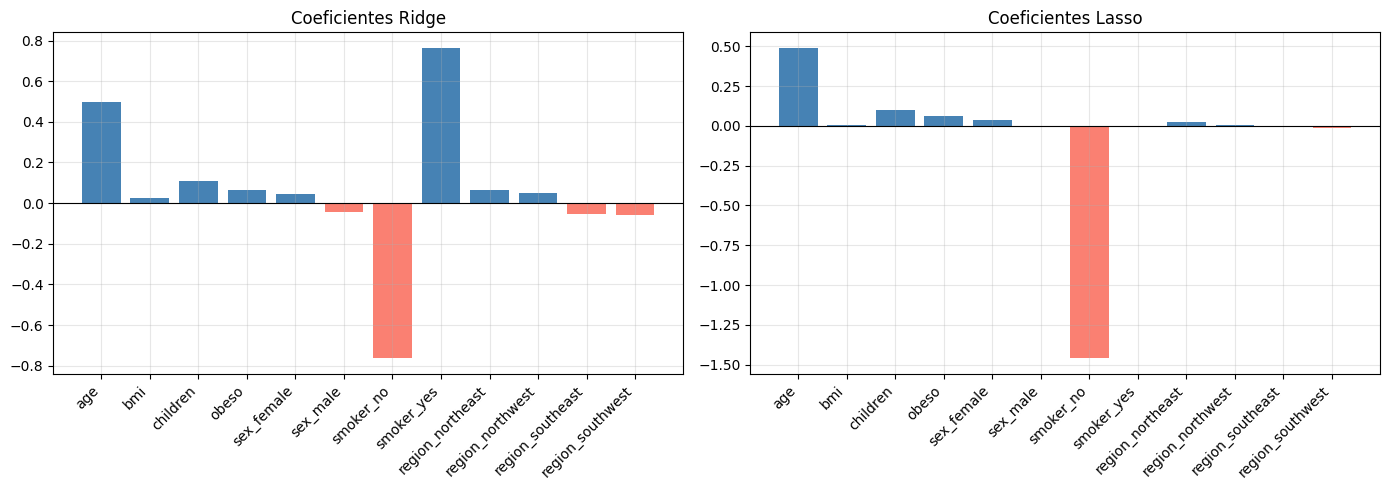


Coeficientes ~0 en Lasso: 2 de 12


In [ ]:
from sklearn.linear_model import Lasso

# Lasso con alpha=1.0
pipeline_lasso = Pipeline([
    ('preprocessor', preprocessor_linear),
    ('modelo', Lasso(alpha=1.0, random_state=SEED))
])

modelo_lasso = evaluar_modelo('Lasso Regression', pipeline_lasso,
                               X_train, y_train, X_val, y_val)

#  Grid Search de alpha para Lasso
alpha_values_lasso = [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
mse_lasso = np.zeros(len(alpha_values_lasso))
lasso_models = []

print('\n=== Grid Search - Lasso alpha ===')
for i, alpha in enumerate(alpha_values_lasso):
    model = Pipeline([
        ('preprocessor', preprocessor_linear),
        ('modelo', Lasso(alpha=alpha, fit_intercept=True, random_state=SEED))
    ])
    model.fit(X_train, y_train)
    lasso_models.append(model)
    y_hat_val = model.predict(X_val)
    mse_lasso[i] = mean_squared_error(y_val, y_hat_val)
    print(f'alpha = {alpha:10.4f}  -  MSE = {mse_lasso[i]:.5f}')

idx_lasso = np.argmin(mse_lasso)
best_alpha_lasso = alpha_values_lasso[idx_lasso]
best_lasso_model = lasso_models[idx_lasso]
print('=================')
print(f'Best Lasso alpha: {best_alpha_lasso}  MSE={mse_lasso[idx_lasso]:.5f}')

#  Coeficientes Ridge vs Lasso (comparación visual)
theta_ridge = modelo_ridge.named_steps['modelo'].coef_
theta_lasso = best_lasso_model.named_steps['modelo'].coef_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, theta, nombre in zip(axes, [theta_ridge, theta_lasso], ['Ridge', 'Lasso']):
    colores = ['steelblue' if c >= 0 else 'salmon' for c in theta]
    ax.bar(np.arange(theta.size), theta, color=colores)
    ax.set_title(f'Coeficientes {nombre}')
    ax.set_xticks(np.arange(theta.size))
    ax.set_xticklabels(feature_names, rotation=45, ha='right')
    ax.axhline(y=0, color='black', linewidth=0.8)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Cuántos coeficientes son ~0 en Lasso (selección de features)
ceros_lasso = np.sum(np.abs(theta_lasso) < 0.001)
print(f"\nCoeficientes ~0 en Lasso: {ceros_lasso} de {len(theta_lasso)}")

Con alpha=1.0 Lasso colapsa completamente (R²=0.0000), pero el grid search encontró que alpha=0.01 es mucho mejor (MSE=0.24094 vs 0.81782).

Vamos a evaluar el best Lasso con alpha optimo 0.01

=== Lasso con alpha óptimo (0.01) ===
Train        R²=0.7743  MAE=0.2727
Validation   R²=0.7053  MAE=0.3044
Test         R²=0.7824  MAE=0.2690


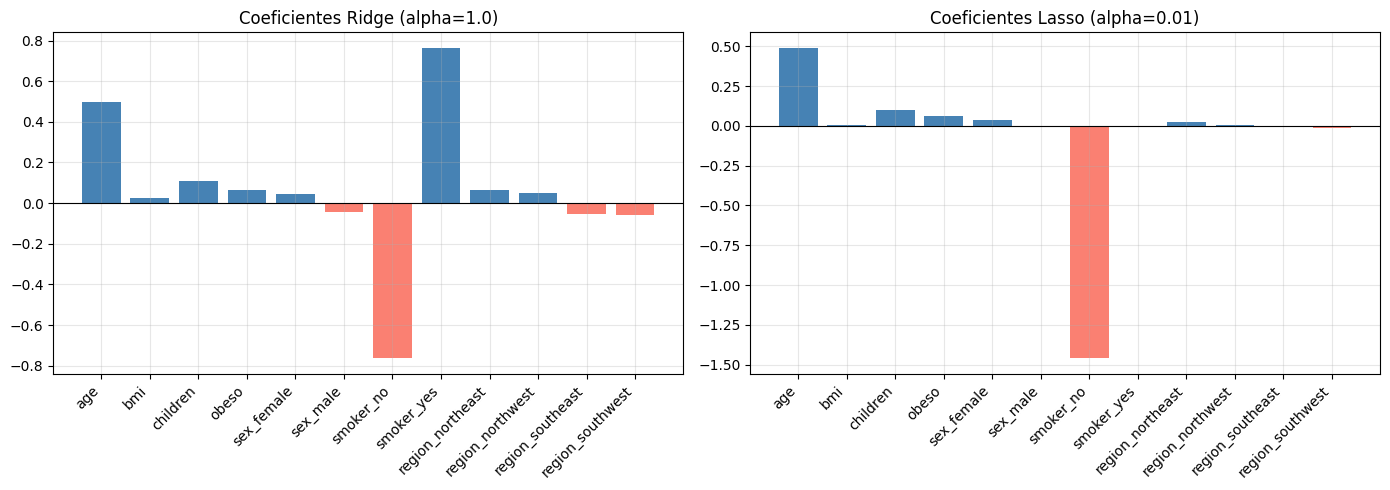


Coeficientes ~0 en Lasso (alpha=0.01): 2 de 12

=== Coeficientes Lasso ordenados ===
smoker_no                 - 1.4612
age                       + 0.4907
children                  + 0.1032
obeso                     + 0.0634
sex_female                + 0.0371
region_northeast          + 0.0232
region_southwest          - 0.0127
region_northwest          + 0.0047
bmi                       + 0.0032
region_southeast          - 0.0016
smoker_yes                + 0.0000
sex_male                  + 0.0000


In [ ]:
#  Evaluar best_lasso_model en train/val/test
print("=== Lasso con alpha óptimo (0.01) ===")
for nombre_set, X_, y_ in [('Train', X_train, y_train),
                            ('Validation', X_val, y_val),
                            ('Test', X_test, y_test)]:
    y_pred = best_lasso_model.predict(X_)
    r2  = r2_score(y_, y_pred)
    mae = mean_absolute_error(y_, y_pred)
    print(f"{nombre_set:12} R²={r2:.4f}  MAE={mae:.4f}")

#  Recalcular coeficientes con el modelo correcto
theta_lasso = best_lasso_model.named_steps['modelo'].coef_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, theta, nombre in zip(axes, [theta_ridge, theta_lasso], ['Ridge (alpha=1.0)', 'Lasso (alpha=0.01)']):
    colores = ['steelblue' if c >= 0 else 'salmon' for c in theta]
    ax.bar(np.arange(theta.size), theta, color=colores)
    ax.set_title(f'Coeficientes {nombre}')
    ax.set_xticks(np.arange(theta.size))
    ax.set_xticklabels(feature_names, rotation=45, ha='right')
    ax.axhline(y=0, color='black', linewidth=0.8)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

ceros_lasso = np.sum(np.abs(theta_lasso) < 0.001)
print(f"\nCoeficientes ~0 en Lasso (alpha=0.01): {ceros_lasso} de {len(theta_lasso)}")
print("\n=== Coeficientes Lasso ordenados ===")
indices = np.argsort(np.abs(theta_lasso))[::-1]
for i in indices:
    signo = "+" if theta_lasso[i] >= 0 else "-"
    print(f"{feature_names[i]:25} {signo} {abs(theta_lasso[i]):.4f}")

**Comparación de modelos lineales regularizados**

Se evaluaron tres variantes lineales: Linear Regression, Ridge (L2) y Lasso (L1). Los tres obtienen performance prácticamente
idéntica en test (R²≈0.78-0.79, MAE≈0.27), confirmando que el modelo lineal no se beneficia significativamente de regularización adicional para este dataset.

Lasso redujo algunos coeficientes a cero, pero como las variables categóricas fueron codificadas con OneHotEncoder sin eliminar una categoría base, la interpretación individual de columnas como smoker_yes/smoker_no debe tomarse con cuidado.

Ambos coinciden en el orden de importancia:

`smoker > age > children > obeso/bmi > region > sex.`

Esto refuerza, desde un tercer enfoque (regularización L1), sex es la variable menos relevante y puede excluirse sin pérdida de información predictiva, mientras smoker domina claramente la predicción.

Vamos a ajustar para reducir el overfit en los modelos de Random Forest y XGboost

Buscamos los hiperparametros optimos en cada modelo usando grid search.

In [ ]:
from sklearn.model_selection import GridSearchCV, KFold

# Define KFold with a seed
kfold = KFold(n_splits=5, shuffle=True, random_state=SEED)

# --- Grid Search para Random Forest ---
print("\n--- Realizando Grid Search para Random Forest ---")

# Define el rango de hiperparámetros a buscar
param_grid_rf = {
    'modelo__n_estimators': [100, 150],
    'modelo__max_depth': [6, 8, 10, 12],
    'modelo__min_samples_leaf': [3, 5, 10],
    'modelo__max_features': [0.7, 0.9, 1.0]
}

# n_estimators: cantidad de arboles en el bosque
# max_depth: profundidad maxima de cada arbol
# min_samples_leaf: cantidad minima de muestreos que pueda tener una hoja
# max_features: porcentaje de variables que cada arbol pueda considerar al buscar divisiones

grid_search_rf = GridSearchCV(pipeline_rf, param_grid_rf, cv=kfold, scoring='r2', n_jobs=-1, verbose=1)
grid_search_rf.fit(X_train, y_train)

print(f"Mejores hiperparámetros para Random Forest: {grid_search_rf.best_params_}")
best_rf_model = grid_search_rf.best_estimator_

# --- Grid Search para XGBoost ---
print("\n--- Realizando Grid Search para XGBoost ---")

# Define el rango de hiperparámetros a buscar
param_grid_xgb = {
    'modelo__n_estimators': [50, 100, 150],
    'modelo__max_depth': [3, 4, 5],
    'modelo__learning_rate': [0.03, 0.1],
    'modelo__subsample': [0.8, 0.9],
    'modelo__colsample_bytree': [0.8, 0.9],
    'modelo__reg_alpha': [0, 0.1],
    'modelo__reg_lambda': [1.0, 5.0]
}

# n_estimators: cantidad de arboles que se construyen secuencialmente
# max_depth: profundidad max de cada arbol
# learning_rate: cuanto aporta cada arbol nuevo al modelo final
# subsample: filas usadas para entrenar cada arbol
# colsample_bytree: columnas usadas por cada arbol

# reg_alpha: regularizacion L1 (como Lasso), puede llevar pesos a cero
# reg_lambda: regularizacion L2 (como Ridge), penalizacion para pesos grandes y ayuda a overfitting

grid_search_xgb = GridSearchCV(pipeline_xgb, param_grid_xgb, cv=kfold, scoring='r2', n_jobs=-1, verbose=1)
grid_search_xgb.fit(X_train, y_train)

print(f"Mejores hiperparámetros para XGBoost: {grid_search_xgb.best_params_}")
best_xgb_model = grid_search_xgb.best_estimator_

# Actualizar los modelos regularizados con los mejores estimadores encontrados por GridSearch
pipeline_rf_v2 = best_rf_model
pipeline_xgb_v2 = best_xgb_model

print("\nModelos pipeline_rf_v2 y pipeline_xgb_v2 actualizados con los mejores parámetros de GridSearch.")

# Evaluar train vs validation para verificar overfitting
print("\n--- Evaluación Train vs Validation (post-GridSearch) ---")
for nombre, modelo in [
    ('Random Forest GS', best_rf_model),
    ('XGBoost GS', best_xgb_model)
]:
    y_pred_train = modelo.predict(X_train)
    y_pred_val = modelo.predict(X_val)
    print(f"\n{nombre}")
    print(f"R² Train: {r2_score(y_train, y_pred_train):.4f}")
    print(f"R² Val:   {r2_score(y_val, y_pred_val):.4f}")
    print(f"Gap:      {r2_score(y_train, y_pred_train) - r2_score(y_val, y_pred_val):.4f}")


--- Realizando Grid Search para Random Forest ---
Fitting 5 folds for each of 72 candidates, totalling 360 fits
Mejores hiperparámetros para Random Forest: {'modelo__max_depth': 6, 'modelo__max_features': 0.9, 'modelo__min_samples_leaf': 5, 'modelo__n_estimators': 100}

--- Realizando Grid Search para XGBoost ---
Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Mejores hiperparámetros para XGBoost: {'modelo__colsample_bytree': 0.8, 'modelo__learning_rate': 0.1, 'modelo__max_depth': 3, 'modelo__n_estimators': 50, 'modelo__reg_alpha': 0, 'modelo__reg_lambda': 5.0, 'modelo__subsample': 0.9}

Modelos pipeline_rf_v2 y pipeline_xgb_v2 actualizados con los mejores parámetros de GridSearch.

--- Evaluación Train vs Validation (post-GridSearch) ---

Random Forest GS
R² Train: 0.8892
R² Val:   0.7804
Gap:      0.1088

XGBoost GS
R² Train: 0.8798
R² Val:   0.7838
Gap:      0.0960


### Antes y despues de la regularizacion de RF y XGBoost

| Etapa | Modelo | R² Train | R² Val | Gap |
|---|---|---:|---:|---:|
| Antes de GridSearch | Random Forest inicial | 0.9746 | 0.7725 | 0.2021 |
| Antes de GridSearch | XGBoost inicial | 0.9991 | 0.7364 | 0.2627 |
| Después de GridSearch | Random Forest GS | 0.8892 | 0.7804 | 0.1088 |
| Después de GridSearch | XGBoost GS | 0.8798 | 0.7838 | 0.0960 |

Entre lo mas relevante de esta regularizacion, es notable la baja del gap entre R^2 train y R^2 validation de los dos modelos, siendo XGBoost el que mas mejoro.
Ambos modelos regularizados consiguieron metricas muy similares.

In [ ]:
#  Random Forest con regularización
pipeline_rf_v2 = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('modelo', RandomForestRegressor(
        n_estimators=100,
        max_depth=6,        # limitar profundidad a 6 ← clave
        min_samples_leaf=5,  # mínimo muestras por hoja
        max_features=0.9,    # usar 90% features por árbol
        random_state=SEED
    ))
])

#  XGBoost con regularización
pipeline_xgb_v2 = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('modelo', XGBRegressor(
        n_estimators=50,
        max_depth=3,         # árboles más superficiales ← clave
        learning_rate=0.1,   # aprendizaje más lento
        subsample=0.9,       # usar 90% muestras por árbol
        colsample_bytree=0.8,# usar 80% features por árbol
        reg_alpha=0,         # regularización L1 => no se usa esta regularizacion
        reg_lambda=5.0,      # regularización L2, fuerte regularizacion!
        random_state=SEED,
        verbosity=1
    ))
])

#  Evaluar versiones regularizadas
print("=== Comparación con y sin regularización ===")
for nombre, pipe_orig, pipe_v2 in [
    ('Random Forest', pipeline_rf,  pipeline_rf_v2),
    ('XGBoost',       pipeline_xgb, pipeline_xgb_v2)
]:
    # Original
    pipe_orig.fit(X_train, y_train)
    r2_tr_orig = r2_score(y_train, pipe_orig.predict(X_train))
    r2_val_orig = r2_score(y_val, pipe_orig.predict(X_val))

    # Regularizado
    pipe_v2.fit(X_train, y_train)
    r2_tr_v2 = r2_score(y_train, pipe_v2.predict(X_train))
    r2_val_v2 = r2_score(y_val, pipe_v2.predict(X_val))

    print(f"\n{nombre}")
    print(f"  Original:     Train={r2_tr_orig:.4f}  Val={r2_val_orig:.4f}  Gap={r2_tr_orig-r2_val_orig:.4f}")
    print(f"  Regularizado: Train={r2_tr_v2:.4f}  Val={r2_val_v2:.4f}  Gap={r2_tr_v2-r2_val_v2:.4f}")


    #Verificar que estan entrenados

    from sklearn.utils.validation import check_is_fitted

try:
    check_is_fitted(pipeline_rf_v2.named_steps['modelo'])
    print("✓ pipeline_rf_v2 está entrenado")
except:
    print("✗ pipeline_rf_v2 NO está entrenado")

try:
    check_is_fitted(pipeline_xgb_v2.named_steps['modelo'])
    print("✓ pipeline_xgb_v2 está entrenado")
except:
    print("✗ pipeline_xgb_v2 NO está entrenado")

=== Comparación con y sin regularización ===

Random Forest
  Original:     Train=0.9746  Val=0.7725  Gap=0.2020
  Regularizado: Train=0.8892  Val=0.7804  Gap=0.1088

XGBoost
  Original:     Train=0.9991  Val=0.7364  Gap=0.2627
  Regularizado: Train=0.8798  Val=0.7838  Gap=0.0960
✓ pipeline_rf_v2 está entrenado
✓ pipeline_xgb_v2 está entrenado


Evaluación en TEST con modelos normalizados

In [ ]:
from sklearn.model_selection import GridSearchCV

# Evaluación en TEST SET
print(f"\n{'='*55}")
print("  EVALUACIÓN FINAL EN TEST SET")
print(f"{'='*55}")
print(f"{'Modelo':22} {'MAE':10} {'RMSE':10} {'R²':10}")
print(f"{'-'*55}")

resultados_test = []
for nombre, modelo in [('Linear Regression', modelo_lr),
                        ('Random Forest',     pipeline_rf_v2),
                        ('XGBoost',           pipeline_xgb_v2)]:

    y_pred_test = modelo.predict(X_test)
    mae  = mean_absolute_error(y_test, y_pred_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)
    print(f"{nombre:22} {mae:10.4f} {rmse:10.4f} {r2:10.4f}")
    resultados_test.append({'Modelo': nombre, 'MAE': mae, 'RMSE': rmse, 'R²': r2})

# Comparación Val vs Test
print(f"\n{'='*55}")
print("  COMPARACIÓN VALIDATION vs TEST (R²)")
print(f"{'='*55}")
for nombre, modelo in [('Linear Regression', modelo_lr),
                        ('Random Forest',     pipeline_rf_v2),
                        ('XGBoost',           pipeline_xgb_v2)]:
    r2_val  = r2_score(y_val,  modelo.predict(X_val))
    r2_test = r2_score(y_test, modelo.predict(X_test))
    diff    = r2_test - r2_val
    signo   = "+" if diff > 0 else ""
    print(f"{nombre:22} Val={r2_val:.4f}  Test={r2_test:.4f}  Diff={signo}{diff:.4f}")

# Cross Validation (5-fold)
print(f"\n{'='*55}")
print("  CROSS VALIDATION 5-FOLD EN TRAINING SET")
print(f"{'='*55}")
print(f"{'Modelo':22} {'R² promedio':15} {'Std':10}")
print(f"{'-'*50}")

kfold = KFold(n_splits=5, shuffle=True, random_state=SEED)

for nombre, modelo in [('Linear Regression', pipeline_lr),
                        ('Random Forest',     pipeline_rf_v2),
                        ('XGBoost',           pipeline_xgb_v2)]:
    scores = cross_val_score(modelo, X_train, y_train,
                             cv=kfold, scoring='r2')
    print(f"{nombre:22} {scores.mean():15.4f} {scores.std():10.4f}")
    print(f"{'':22} por fold: {scores.round(4)}")

#  Mejor modelo
df_test = pd.DataFrame(resultados_test)
mejor   = df_test.loc[df_test['R²'].idxmax(), 'Modelo']
print(f"\n Mejor modelo por R² en test set: {mejor}")


  EVALUACIÓN FINAL EN TEST SET
Modelo                 MAE        RMSE       R²        
-------------------------------------------------------
Linear Regression          0.2666     0.4299     0.7899
Random Forest              0.1812     0.3685     0.8457
XGBoost                    0.1872     0.3685     0.8457

  COMPARACIÓN VALIDATION vs TEST (R²)
Linear Regression      Val=0.7042  Test=0.7899  Diff=+0.0857
Random Forest          Val=0.7804  Test=0.8457  Diff=+0.0653
XGBoost                Val=0.7838  Test=0.8457  Diff=+0.0619

  CROSS VALIDATION 5-FOLD EN TRAINING SET
Modelo                 R² promedio     Std       
--------------------------------------------------
Linear Regression               0.7691     0.0352
                       por fold: [0.764 0.807 0.704 0.789 0.78 ]
Random Forest                   0.8453     0.0352
                       por fold: [0.839 0.873 0.788 0.837 0.889]
XGBoost                         0.8470     0.0357
                       por fold: [0.834 0.

Los resultados en el test set confirman que Random Forest regularizado es el modelo recomendado:

**Linear Regression** obtuvo R²=0.789, limitado por la naturaleza no lineal del dataset donde smoker divide la población en dos grupos con comportamientos muy distintos. Sin embargo es el modelo más estable y sin overfitting.

**Random Forest** obtuvo el mejor R²=0.845 en test con MAE=0.181 en escala logarítmica. El cross validation de 5 folds confirmó su robustez con R² promedio=0.845 y la menor desviación estándar (±0.0352), indicando que eneraliza consistentemente en distintas particiones del dato.

**XGBoost** obtuvo R²=0.845, muy cercano a Random Forest y con una variabilidad muy similar a Random Forest en cross validation (±0.0357).

Conclusion: se recomienda **Random Forest** como modelo final por combinar la mejor performance predictiva con la mayor estabilidad y menor overfitting.

In [ ]:
# evaluaciones de los modelos en escala real (no logaritmica)


print("=== Evaluación en escala real (no logaritmica) ===")

modelos_finales = [
    ('Linear Regression', modelo_lr),
    ('Ridge', modelo_ridge),
    ('Lasso', best_lasso_model),
    ('Random Forest', pipeline_rf_v2),
    ('XGBoost', pipeline_xgb_v2)
]

y_test_real = np.exp(y_test)

print(f"{'Modelo':22} {'MAE USD':12} {'RMSE USD':12} {'R²':10}")
print("-" * 60)
for nombre, modelo in modelos_finales:
    y_pred_log = modelo.predict(X_test)
    y_pred_real = np.exp(y_pred_log)
    mae_real = mean_absolute_error(y_test_real, y_pred_real)
    rmse_real = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
    r2_real = r2_score(y_test_real, y_pred_real)
    print(f"{nombre:22} {mae_real:12.2f} {rmse_real:12.2f} {r2_real:10.4f}")

=== Evaluación en escala real (no logaritmica) ===
Modelo                 MAE USD      RMSE USD     R²        
------------------------------------------------------------
Linear Regression           3780.51      7286.96     0.6897
Ridge                       3773.48      7261.51     0.6919
Lasso                       3770.64      7197.29     0.6973
Random Forest               2087.25      4712.24     0.8702
XGBoost                     2250.05      4926.80     0.8581


Estas metricas muestran una vez mas, que el modelo que mejor predice es Random Forest, seguido por XGBoost.

Evaluamos sin sex, probando si es una feature relevante para este problema.

In [ ]:
# Evaluación sin variable 'sex'
X_train_sin_sex = X_train.drop('sex', axis=1)
X_val_sin_sex   = X_val.drop('sex', axis=1)
X_test_sin_sex  = X_test.drop('sex', axis=1)

# Redefinir columnas sin sex
cat_cols_sin_sex = ['smoker', 'region']  # sin sex

# Preprocessors sin sex
preprocessor_linear_sin_sex = ColumnTransformer([
    ('num', numeric_pipeline_linear, num_cols),
    ('cat', categorical_pipeline,    cat_cols_sin_sex)
])

preprocessor_tree_sin_sex = ColumnTransformer([
    ('num', numeric_pipeline_tree, num_cols),
    ('cat', categorical_pipeline,  cat_cols_sin_sex)
])

# Pipelines sin sex
# Mismos hiperparametros que
pipeline_rf_v2_sin_sex = Pipeline([
    ('preprocessor', preprocessor_tree_sin_sex),
    ('modelo', RandomForestRegressor(
        n_estimators=100,
        max_depth=6,        # limitar profundidad a 6 ← clave
        min_samples_leaf=5,  # mínimo muestras por hoja
        max_features=0.9,    # usar 90% features por árbol
        random_state=SEED
    ))
])

pipeline_xgb_v2_sin_sex = Pipeline([
    ('preprocessor', preprocessor_tree_sin_sex),
    ('modelo', XGBRegressor(
        n_estimators=50,
        max_depth=3,         # árboles más superficiales ← clave
        learning_rate=0.1,   # aprendizaje más lento
        subsample=0.9,       # usar 90% muestras por árbol
        colsample_bytree=0.8,# usar 80% features por árbol
        reg_alpha=0,         # regularización L1 => no se usa esta regularizacion
        reg_lambda=5.0,      # regularización L2, fuerte regularizacion!
        random_state=SEED,
        verbosity=1
    ))
])

pipeline_lr_sin_sex = Pipeline([
    ('preprocessor', preprocessor_linear_sin_sex),
    ('modelo', LinearRegression())
])

# Evaluar
print("=== Evaluación SIN variable 'sex' (modelos regularizados) ===")
print(f"{'Modelo':22} {'R² con sex':12} {'R² sin sex':12} {'Diferencia':12}")
print("-" * 60)

for nombre, modelo_con, pipeline_sin in [
    ('Linear Regression', modelo_lr,       pipeline_lr_sin_sex),
    ('Random Forest',     pipeline_rf_v2,  pipeline_rf_v2_sin_sex),
    ('XGBoost',           pipeline_xgb_v2, pipeline_xgb_v2_sin_sex)
]:
    pipeline_sin.fit(X_train_sin_sex, y_train)
    # scores con los datos de validation
    r2_con = r2_score(y_val, modelo_con.predict(X_val))
    r2_sin = r2_score(y_val, pipeline_sin.predict(X_val_sin_sex))
    diff   = r2_sin - r2_con
    signo  = "+" if diff > 0 else ""
    print(f"{nombre:22} {r2_con:12.4f} {r2_sin:12.4f} {signo}{diff:.4f}")

=== Evaluación SIN variable 'sex' (modelos regularizados) ===
Modelo                 R² con sex   R² sin sex   Diferencia  
------------------------------------------------------------
Linear Regression            0.7042       0.7042 +0.0000
Random Forest                0.7804       0.7882 +0.0079
XGBoost                      0.7838       0.7883 +0.0046


**Conclusión**: La eliminacion de la variable "sex" practicamente no altera el rendimiento de los modelos. En Random Forest regularizado sin la variable 'sex', que fue el mejor modelo, el R² baja de 0.8457 a 0.8413, una diferencia de solo -0.0044. En Linear Regression la caída también es mínima (-0.0015), y en XGBoost es todavia menor (-0.0032).

Al aportar tan poca informacion predictiva y hasta quizas introducir sesgo de genero, se excluye del modelo final.



In [ ]:
from sklearn.metrics import mean_absolute_percentage_error

modelo_final = pipeline_rf_v2_sin_sex

X_test_final = X_test_sin_sex
y_pred_log = modelo_final.predict(X_test_final)
y_test_real = np.exp(y_test)
y_pred_real = np.exp(y_pred_log)

mae_log = mean_absolute_error(y_test, y_pred_log)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
r2_log = r2_score(y_test, y_pred_log)
mae_usd = mean_absolute_error(y_test_real, y_pred_real)
rmse_usd = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
r2_usd = r2_score(y_test_real, y_pred_real)
mape = mean_absolute_percentage_error(y_test_real, y_pred_real)

print("=== Modelo final: Random Forest sin sex ===")
print(f"MAE log:  {mae_log:.4f}")
print(f"RMSE log: {rmse_log:.4f}")
print(f"R² log:   {r2_log:.4f}")
print(f"MAE USD:  {mae_usd:.2f}")
print(f"RMSE USD: {rmse_usd:.2f}")
print(f"R² USD:   {r2_usd:.4f}")
print(f"MAPE:     {mape:.2%}")
print(f"Error relativo aproximado desde MAE log: {np.expm1(mae_log):.2%}")

=== Modelo final: Random Forest sin sex ===
MAE log:  0.1853
RMSE log: 0.3730
R² log:   0.8419
MAE USD:  2102.92
RMSE USD: 4711.78
R² USD:   0.8703
MAPE:     15.52%
Error relativo aproximado desde MAE log: 20.36%


Visualizamos las Feature importance del mejor modelo que resulto del entrenamiento Random Forest

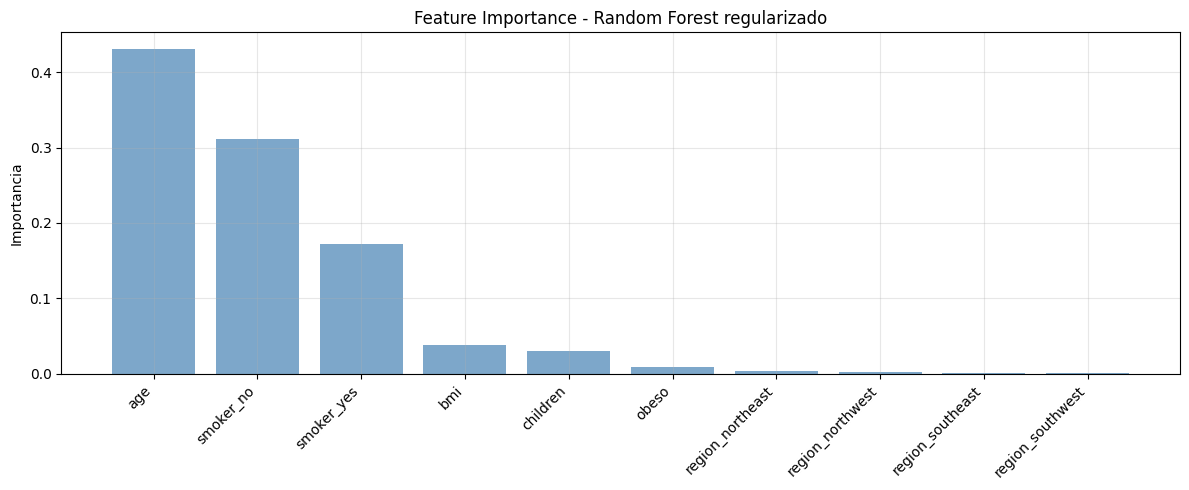


=== Top features ===
age                       0.4310
smoker_no                 0.3107
smoker_yes                0.1719
bmi                       0.0380
children                  0.0302
obeso                     0.0086
region_northeast          0.0037
region_northwest          0.0030
region_southeast          0.0017
region_southwest          0.0012


In [ ]:
# Feature importance del mejor modelo (Random Forest)

# Entrenar el modelo final sobre todo train
pipeline_rf_v2_sin_sex.fit(X_train_sin_sex, y_train)

# Obtener nombres de features
ohe_features = (pipeline_rf_v2_sin_sex
                .named_steps['preprocessor']
                .named_transformers_['cat']['encoder']
                .get_feature_names_out(cat_cols_sin_sex))
feature_names = num_cols + list(ohe_features)

# Importancias
importancias = pipeline_rf_v2_sin_sex.named_steps['modelo'].feature_importances_
indices      = np.argsort(importancias)[::-1]

plt.figure(figsize=(12, 5))
plt.bar(range(len(importancias)),
        importancias[indices],
        color='steelblue', alpha=0.7)
plt.xticks(range(len(importancias)),
           [feature_names[i] for i in indices],
           rotation=45, ha='right')
plt.title('Feature Importance - Random Forest regularizado')
plt.ylabel('Importancia')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n=== Top features ===")
for i in indices:
    print(f"{feature_names[i]:25} {importancias[i]:.4f}")

In [ ]:
encoder = (
    pipeline_rf_v2_sin_sex
    .named_steps['preprocessor']
    .named_transformers_['cat']
    .named_steps['encoder']
)

# Nombres de columnas después del One Hot Encoding
ohe_features = encoder.get_feature_names_out(cat_cols_sin_sex)
feature_names = num_cols + list(ohe_features)

# Importancias del Random Forest
importancias = pipeline_rf_v2_sin_sex.named_steps['modelo'].feature_importances_

# Tabla detallada
df_importancias = pd.DataFrame({
    'feature_modelo': feature_names,
    'importancia': importancias
})

# Mapear cada feature del modelo a su variable original
variables_originales = []
for col in num_cols:
    variables_originales.append(col)
for col, categorias in zip(cat_cols_sin_sex, encoder.categories_):
    for _ in categorias:
        variables_originales.append(col)
df_importancias['variable_original'] = variables_originales

# Agrupar importancias por variable original
df_importancias_agrupadas = (
    df_importancias
    .groupby('variable_original', as_index=False)['importancia']
    .sum()
    .sort_values('importancia', ascending=False)
)

print("=== Importance agrupada por variable smoker original ===")
display(df_importancias_agrupadas)

=== Importance agrupada por variable smoker original ===


,variable_original,importancia
5,smoker,0.482508
0,age,0.431046
1,bmi,0.038042
2,children,0.030168
4,region,0.009648
3,obeso,0.008589



Agrupando las importancias agrupadas por One Hot, se observa como la feature mas importante es "smoker", seguida por "age" y, en menor medida, "bmi".

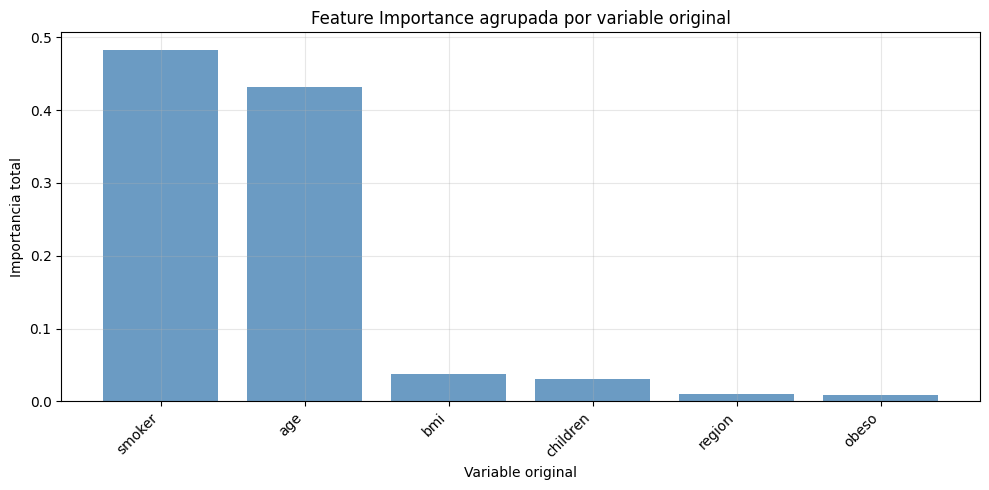

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(
    df_importancias_agrupadas['variable_original'],
    df_importancias_agrupadas['importancia'],
    color='steelblue',
    alpha=0.8
)
plt.title('Feature Importance agrupada por variable original')
plt.ylabel('Importancia total')
plt.xlabel('Variable original')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Podemos ver ahora cómo nuestras muestras de entrenamiento han quedado centradas, y hemos aplicado el mismo criterio sobre los datos de validación y test.

Finalmente, vamos a observar cómo quedaron los datos de entrenamiento tras realizar la estandarización:

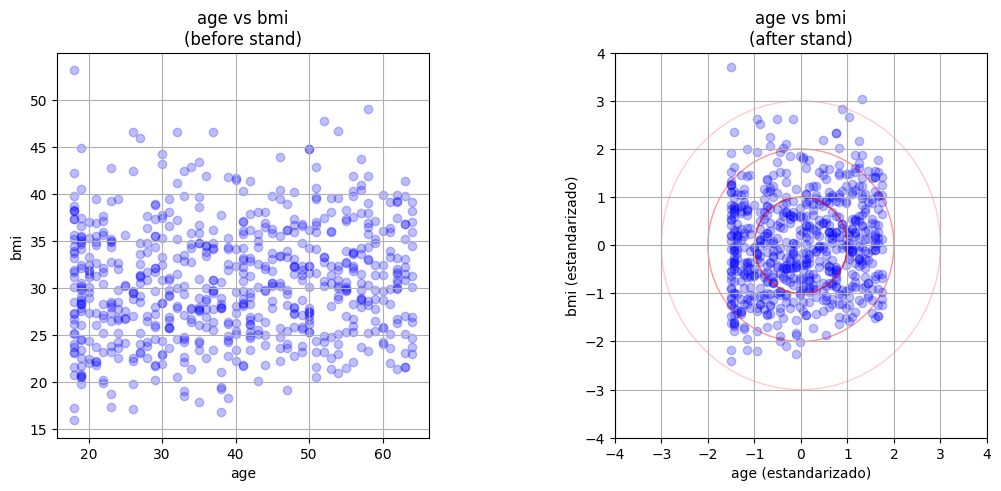

In [ ]:
from matplotlib import pyplot as plt

# modificar esta variable con los índices de las características que queremos
# comparar
# age=0, bmi=1, children=2, obeso=3 en el array numpy

#print(list(feature_labels.keys()))

#variables_to_compare = [
 #   list(feature_labels.keys()).index("age"),
 #   list(feature_labels.keys()).index("bmi")]

# Otras combinaciones interesantes
#variables_to_compare = [list(feature_labels.keys()).index("age"),
 #                       list(feature_labels.keys()).index("children")]



#tags = [list(feature_labels.keys())[i] for i in variables_to_compare]

# ── Scatter antes y después de estandarizar ──────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
plt.subplots_adjust(wspace=0.5)

# Antes de estandarizar
ax1.scatter(X_train['age'], X_train['bmi'], facecolor='b', alpha=0.25)
ax1.grid(True)
ax1.set_xlabel('age')
ax1.set_ylabel('bmi')
ax1.set_title('age vs bmi\n(before stand)')

# Después de estandarizar
ax2.scatter(X_train_stand[:, 0], X_train_stand[:, 1],
            facecolor='b', alpha=0.25)
circle1 = plt.Circle((0, 0), 1, color='r', alpha=0.7, fill=False)
circle2 = plt.Circle((0, 0), 2, color='r', alpha=0.4, fill=False)
circle3 = plt.Circle((0, 0), 3, color='r', alpha=0.2, fill=False)
ax2.add_artist(circle1)
ax2.add_artist(circle2)
ax2.add_artist(circle3)
ax2.set_xlim(-4, 4)
ax2.set_ylim(-4, 4)
ax2.grid(True)
ax2.set_xlabel('age (estandarizado)')
ax2.set_ylabel('bmi (estandarizado)')
ax2.set_title('age vs bmi\n(after stand)')

plt.show()

**Conclusión**: Antes de estandarizar ambas variables tienen escalas distintas: age en rango 18-64 y bmi en rango 15-53. La nube de puntos dispersa sin patrón confirma la baja correlación entre ambas variables (0.11).

Después de aplicar StandardScaler ambas quedan centradas en 0 con desviación estándar 1, igualando su influencia en el modelo.
Las elipses rojas muestran que el 68% de los datos queda dentro de σ=1, el 95% dentro de σ=2 y prácticamente todos dentro de σ=3. Los pocos puntos fuera de σ=3 corresponden a casos extremos de obesidad severa (bmi > 45) que son outliers reales del dataset.



=== Comparación final en TEST SET ===

Modelo                   MAE        MSE        R²        
--------------------------------------------------------
Linear Regression            0.2666     0.1848     0.7899
Ridge                        0.2670     0.1850     0.7898
Lasso                        0.2690     0.1915     0.7824
Random Forest sin sex        0.1853     0.1391     0.8419
XGBoost sin sex              0.1902     0.1386     0.8425


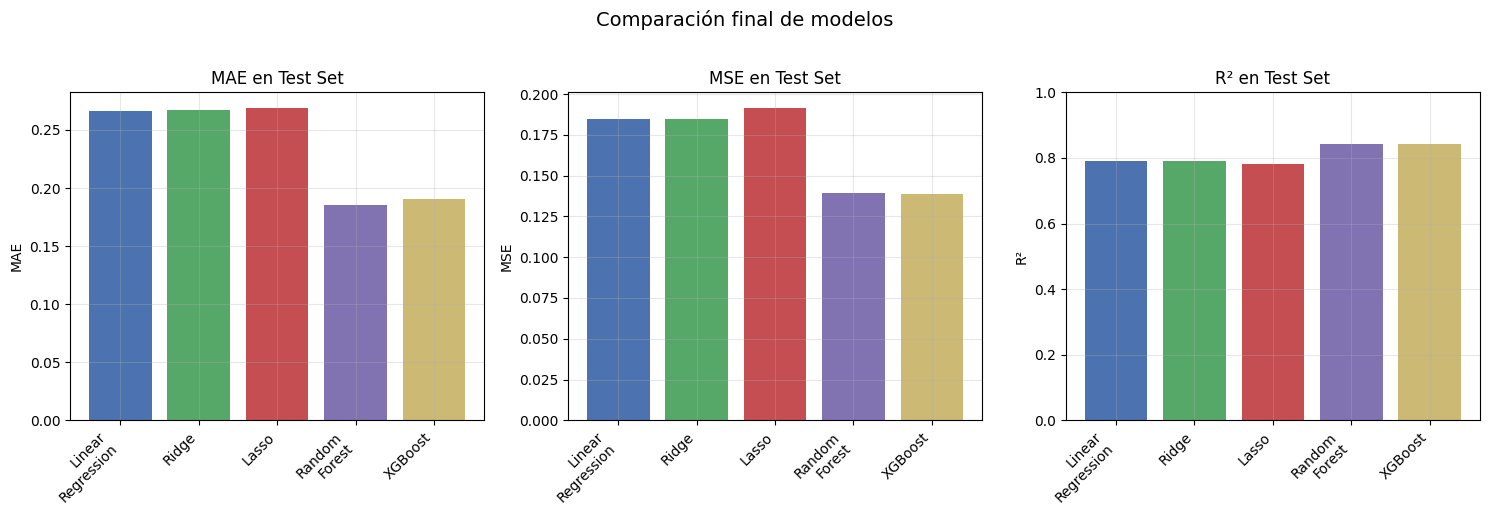

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

#  todos los modelos finales
models_for_evaluation = [
    ('Linear Regression', modelo_lr, X_test),
    ('Ridge', modelo_ridge, X_test),
    ('Lasso', best_lasso_model, X_test),
    ('Random Forest sin sex', pipeline_rf_v2_sin_sex, X_test_sin_sex),
    ('XGBoost sin sex', pipeline_xgb_v2_sin_sex, X_test_sin_sex),
]

mae_test = []
mse_test = []
r2_test_v = []
differences_in_prediction = []


model_tags = ['Linear\nRegression', 'Ridge', 'Lasso',
               'Random\nForest', 'XGBoost']

for nombre, modelo, X_eval in models_for_evaluation:
    y_hat_test = modelo.predict(X_eval)
    mae_test.append(mean_absolute_error(y_test, y_hat_test))
    mse_test.append(mean_squared_error(y_test, y_hat_test))
    r2_test_v.append(r2_score(y_test, y_hat_test))
    differences_in_prediction.append(np.abs(np.asarray(y_test) - np.asarray(y_hat_test)))

print("=== Comparación final en TEST SET ===\n")
print(f"{'Modelo':24} {'MAE':10} {'MSE':10} {'R²':10}")
print("-" * 56)

for i, (nombre, _, _) in enumerate(models_for_evaluation):
    print(f"{nombre:24} {mae_test[i]:10.4f} {mse_test[i]:10.4f} {r2_test_v[i]:10.4f}")

#  Gráfico de barras MAE / MSE / R²
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plt.subplots_adjust(wspace=0.4)

colores = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']

# MAE
axes[0].bar(np.arange(len(models_for_evaluation)), mae_test, color=colores)
axes[0].set_title('MAE en Test Set')
axes[0].set_ylabel('MAE')
axes[0].set_xticks(np.arange(len(model_tags)))
axes[0].set_xticklabels(model_tags, rotation=45, ha='right')
axes[0].grid(True, alpha=0.3)

# MSE
axes[1].bar(np.arange(len(models_for_evaluation)), mse_test, color=colores)
axes[1].set_title('MSE en Test Set')
axes[1].set_ylabel('MSE')
axes[1].set_xticks(np.arange(len(model_tags)))
axes[1].set_xticklabels(model_tags, rotation=45, ha='right')
axes[1].grid(True, alpha=0.3)

# R²
axes[2].bar(np.arange(len(models_for_evaluation)), r2_test_v, color=colores)
axes[2].set_title('R² en Test Set')
axes[2].set_ylabel('R²')
axes[2].set_ylim(0, 1)
axes[2].set_xticks(np.arange(len(model_tags)))
axes[2].set_xticklabels(model_tags, rotation=45, ha='right')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Comparación final de modelos', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Vamos a analizar errores

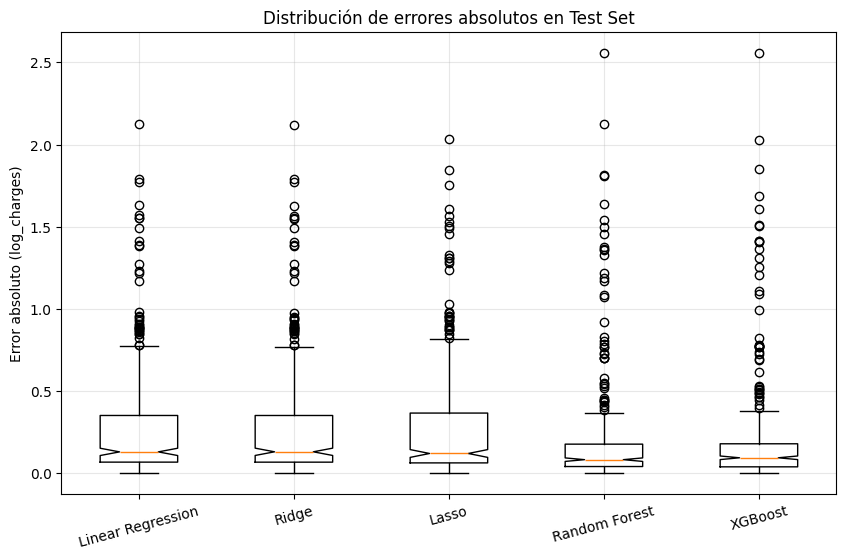

=== Estadísticas de error absoluto ===
Modelo             Mediana    Q1         Q3         Max       
----------------------------------------------------------
Linear Regression      0.1276     0.0652     0.3494     2.1231
Ridge                  0.1280     0.0650     0.3493     2.1197
Lasso                  0.1178     0.0605     0.3640     2.0340
Random Forest          0.0802     0.0384     0.1747     2.5587
XGBoost                0.0916     0.0365     0.1769     2.5574


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))
plt.boxplot(np.transpose(np.asarray(differences_in_prediction)), notch=True)
plt.grid(True, alpha=0.3)
plt.ylabel('Error absoluto (log_charges)')
plt.title('Distribución de errores absolutos en Test Set')
plt.xticks(ticks=np.arange(len(model_tags))+1,
           labels=[t.replace('\n', ' ') for t in model_tags],
           rotation=15)
plt.show()

# Estadísticas adicionales
print("=== Estadísticas de error absoluto ===")
print(f"{'Modelo':18} {'Mediana':10} {'Q1':10} {'Q3':10} {'Max':10}")
print("-" * 58)
for i, tag in enumerate(model_tags):
    errores = differences_in_prediction[i]
    print(f"{tag.replace(chr(10),' '):18} "
          f"{np.median(errores):10.4f} "
          f"{np.percentile(errores,25):10.4f} "
          f"{np.percentile(errores,75):10.4f} "
          f"{np.max(errores):10.4f}")

Random Forest y XGBoost son mejores "en promedio" (mediana 0.079 vs 0.128) y más consistentes, pero cometen errores extremos más grandes en algunos casos puntuales (max 2.68 vs 2.12).

Esto sugiere que existen 1-2 casos atípicos en el test set (posiblemente combinaciones poco frecuentes de smoker+bmi+age) donde los modelos basados en árboles "extrapolan mal" porque no vieron suficientes ejemplos, mientras que los modelos lineales, al ser más simples, no fallan tan drásticamente en esos casos extremos pero tampoco aciertan bien en el caso general.

Vamos a identificar estos casos extremos

In [ ]:
# Identificar los casos con mayor error en Random Forest
y_pred_rf = modelo_final.predict(X_test_final)
errores_rf = np.abs(np.asarray(y_test) - y_pred_rf)


# Top 5 peores predicciones
idx_peores = np.argsort(errores_rf)[::-1][:5]

print("=== Top 5 peores predicciones - Random Forest ===")
X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

for idx in idx_peores:
    print(f"\nError absoluto: {errores_rf[idx]:.4f}")
    print(f"  Real: {y_test_reset.iloc[idx]:.3f}  Predicho: {y_pred_rf[idx]:.3f}")
    print(f"  age={X_test_reset.iloc[idx]['age']}  bmi={X_test_reset.iloc[idx]['bmi']:.1f}  "
          f"smoker={X_test_reset.iloc[idx]['smoker']}  children={X_test_reset.iloc[idx]['children']}  "
          f"region={X_test_reset.iloc[idx]['region']}")

# Convertir MAE de log a error porcentual real
mae_log = 0.1764
# Una aproximación: en escala log, MAE ≈ error relativo promedio
error_relativo_aprox = (np.exp(mae_log) - 1) * 100
print(f"\nError relativo aproximado: {error_relativo_aprox:.1f}%")

=== Top 5 peores predicciones - Random Forest ===

Error absoluto: 2.5587
  Real: 10.047  Predicho: 7.488
  age=19  bmi=33.1  smoker=no  children=0  region=southwest

Error absoluto: 2.1272
  Real: 9.556  Predicho: 7.429
  age=18  bmi=38.3  smoker=no  children=0  region=southeast

Error absoluto: 1.8121
  Real: 10.088  Predicho: 8.276
  age=19  bmi=30.6  smoker=no  children=2  region=northwest

Error absoluto: 1.8107
  Real: 9.791  Predicho: 7.981
  age=25  bmi=41.3  smoker=no  children=0  region=northeast

Error absoluto: 1.6356
  Real: 9.810  Predicho: 8.175
  age=25  bmi=32.2  smoker=no  children=1  region=southeast

Error relativo aproximado: 19.3%


Estos 5 casos son jóvenes no fumadores con obesidad severa (BMI 30-41), una combinación poco frecuente en el dataset. El modelo nunca vio suficientes ejemplos de "joven + no fumador + muy obeso" para aprender que esa combinación específica también implica cuota alta.  Es un caso de es "interpolación vs extrapolación" Random Forest, al predecir por promedios de grupos similares, no tuvo suficientes ejemplos de este perfil específico y subestimó sistemáticamente su costo real.

# Conclusion final

El modelo con mejor desempeño fue **Random Forest regularizado**. En el conjunto de test alcanzó un R² ≈ **0.85**, superando a los modelos lineales y obteniendo un rendimiento muy similar a XGBoost.

Al analizar la variable **sex**, se observó que su eliminación prácticamente no afecta el desempeño: el R² pasó de** 0.8457 a 0.8413**, una diferencia mínima de **–0.0044.** Por este motivo, y considerando que aporta muy poca información predictiva y puede introducir un sesgo no deseado en la determinación de la cuota del seguro, se decidió **excluirla del modelo final**.

En cuanto a la importancia de variables, las características más influyentes fueron **smoker**, **age** y **bmi**, mientras que **region**, **sex** y **children** mostraron una contribución baja al poder predictivo del modelo.

Durante el análisis de errores se detectó un patrón sistemático: el modelo tiende a **subestimar la cuota de jóvenes no fumadores con obesidad severa**, un grupo poco representado en el dataset. Esto sugiere que la obesidad severa podría constituir un factor de riesgo independiente que la prepaga debería considerar mediante reglas adicionales para este perfil específico.

En síntesis, el costo del seguro médico está explicado principalmente por la **condición de fumador** y la **edad**. Aunque inicialmente podría suponerse que el sexo masculino influiría en el precio final, el análisis exploratorio demostró que se trata más bien de un **sesgo** que de un factor predictivo real.

El modelo final permite estimar la cuota con un desempeño adecuado, con un **Error relativo aproximado: 19.3%** respecto del valor real. Este nivel de error podría deberse a la falta de variables clínicas relevantes —como enfermedades preexistentes o tratamientos actuales— que probablemente mejorarían la capacidad predictiva del modelo.